In [32]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import io
import os
import re
import requests
from scipy.signal import savgol_filter

### Functions for data loading, processing

In [ ]:
# where to save temp data 
DS_path = "/tmp"
def get_stab_data(shot_no):
    ds = np.lib.npyio.DataSource(DS_path)

    # Radial
    scope_xinc_url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Infrastructure/PositionStabilization/DAS_raw_data_dir_radial/ScopeSetup/XINC'
    scope_xinc = ds.open(scope_xinc_url, 'rt')
    dt = float(scope_xinc.read())
    scope_xinc.close()

    scope_xor_url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Infrastructure/PositionStabilization/DAS_raw_data_dir_radial/ScopeSetup/XOR'
    scope_xor = ds.open(scope_xor_url, 'rt')
    t_shift = float(scope_xor.read())
    scope_xor.close()

    rad_url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Infrastructure/PositionStabilization/DAS_raw_data_dir_radial/I^radial_currclamp.csv'
    rad_file = ds.open(rad_url)
    stab_rad = pd.read_csv(rad_file.name, names = ['stab_rad'])
    stab_rad['t'] = stab_rad.index.to_numpy() * dt
    stab_rad.t *= 1e3
    stab_rad.t += t_shift * 1e3
    stab_rad.set_index('t', inplace=True)
    rad_file.close()

    # Vertical
    scope_xinc_url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Infrastructure/PositionStabilization/DAS_raw_data_dir_vertical/ScopeSetup/XINC'
    scope_xinc = ds.open(scope_xinc_url, 'rt')
    dt = float(scope_xinc.read())
    scope_xinc.close()

    scope_xor_url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Infrastructure/PositionStabilization/DAS_raw_data_dir_vertical/ScopeSetup/XOR'
    scope_xor = ds.open(scope_xor_url, 'rt')
    t_shift = float(scope_xor.read())
    scope_xor.close()

    vert_url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Infrastructure/PositionStabilization/DAS_raw_data_dir_vertical/I^vertical_currclamp.csv'
    vert_file = ds.open(vert_url)
    stab_vert = pd.read_csv(vert_file.name, names = ['stab_vert'])
    stab_vert['t'] = stab_vert.index.to_numpy() * dt
    stab_vert.t *= 1e3
    stab_vert.t += t_shift * 1e3
    stab_vert.set_index('t', inplace=True)
    vert_file.close()

    return stab_rad, stab_vert

def get_Bt(shot_no):
    ds = np.lib.npyio.DataSource(DS_path)
    url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Diagnostics/BasicDiagnostics/Results/Bt.csv'
    file = ds.open(url, 'rt')
    Bt_df = pd.read_csv(file.name, names=['t', 'Bt'])
    file.close()
    Bt_df.Bt *= 1000
    Bt_df.set_index('t', inplace=True)
    return Bt_df

def get_Ich(shot_no):
    ds = np.lib.npyio.DataSource(DS_path)
    url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Diagnostics/BasicDiagnostics/Results/Ich.csv'
    file = ds.open(url, 'rt')
    Ich_df = pd.read_csv(file.name, names=['t', 'Ich'])
    file.close()
    Ich_df.Ich *= 1000
    Ich_df.set_index('t', inplace=True)
    return Ich_df

def get_comment(shot_no: int) -> str:
    ds = np.lib.npyio.DataSource(DS_path)
    url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/comment'
    try:
        with ds.open(url, 'rt') as comment_file:
            return comment_file.read()
    except Exception:
        return ""
    
def get_param(shot_no :int, p_name, type, ret_on_error):
    ds = np.lib.npyio.DataSource(DS_path)
    try:
        url = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Operation/Discharge/{p_name}'
        with ds.open(url, 'rt') as param_file:
            return type(param_file.read())
    except Exception:
        return ret_on_error

def get_orientations(shot_no :int):
    ds = np.lib.npyio.DataSource(DS_path)
    try:
        url_CD = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Production/Parameters/CD_orientation'
        url_Bt = f'http://golem.fjfi.cvut.cz/shots/{shot_no}/Production/Parameters/Bt_orientation'
        with ds.open(url_CD, 'rt') as CD, ds.open(url_Bt, 'rt') as Bt:
            return CD.read()[:-1], Bt.read()[:-1]
    except Exception:
        return '', ''

def get_disch_params(shot_no: int):
    U_cd = get_param(shot_no, 'U_cd_discharge_request', float, float('nan'))
    U_Bt = get_param(shot_no, 'U_bt_discharge_request', float, float('nan'))
    t_cd = get_param(shot_no, 't_cd_discharge_request', float, float('nan'))
    t_Bt = get_param(shot_no, 't_bt_discharge_request', float, float('nan'))
    
    O_cd, O_Bt = get_orientations(shot_no)
    return U_cd, U_Bt, t_cd, t_Bt, O_cd, O_Bt


In [34]:
def process_file(file_path):
    # Open the file and read its content
    with open(file_path, 'r') as file:
        file_content = file.read()
        file.seek(0)
        file_content_lines = file.readlines()
        
    trigger_pos = 0.
    for line in file_content_lines:
        trigger_pos_regex = re.search(r"Triger position = (\d+,\d+) ms.;",line)
        
        if trigger_pos_regex:
            trigger_pos = float(trigger_pos_regex.group(1).replace(',', '.'))

    
    # Substitute commas with dots
    modified_content = file_content.replace(',', '.')
    
    # Remove tab characters
    modified_content = modified_content.replace('\t', '')
    
    # Create a StringIO buffer with the modified content
    buffer = io.StringIO(modified_content)
    
    # Return the buffer
    return buffer, trigger_pos


In [35]:
def get_msc_file_loc_and_props(shot_no):
    
    msl_data_locs = ['../experiments/2024_04_26/MSL_data',
                     '../experiments/2024_09_16/MSL_data',
                     '../experiments/2024_09_17/MSL_data']

    file_found = False
    for file_loc_idx, file_loc in enumerate(msl_data_locs):
        file_path = os.path.join(file_loc, f'{shot_no}.txt')
        if os.path.isfile(file_path):
            file_found = True
            break

    if not file_found:
        raise FileNotFoundError()


    skiprows_vals = [19,23,23]
    columns = [['t','ref','x','y','z','n'],
               ['t','ref','x','y','z','i','vx','vy','vz','n'],
               ['t','ref','x','y','z','i','vx','vy','vz','n'],
               ]    
    
    return file_path, skiprows_vals[file_loc_idx],columns[file_loc_idx]

In [36]:
def get_hall_probe(shot_no):
    file_path , skiprows, columns = get_msc_file_loc_and_props(shot_no)
    
    file_handle, trigger_time = process_file(file_path)
    hall_probe = pd.read_csv(file_handle, 
                        skiprows=skiprows,
                        delimiter=';',
                        names=columns,
                        index_col='t')
    
    if trigger_time > 0:
        hall_probe.index -= trigger_time
    
        pre_trigger_mean = [hall_probe.loc[:trigger_time-0.1,axis].mean() for axis in 'x y z'.split()]
        for axis, mean in zip('x y z'.split(),pre_trigger_mean):
            hall_probe[axis]-=mean 
    
    return hall_probe

In [37]:
def plot(shot_no, window = 21):
    hall_probe = get_hall_probe(shot_no)
    
    if window > 0:
        for axis in 'x y z'.split():
            hall_probe[axis] = savgol_filter(hall_probe[axis], window_length=window, polyorder=3)
    
    hall_probe=hall_probe[:50.]
    
    
    
    stab_rad, stab_vert = get_stab_data(shot_no=shot_no)
    Bt = get_Bt(shot_no=shot_no)
    Ich = get_Ich(shot_no=shot_no)
    
    comment = get_comment(shot_no=shot_no)

    fig, (ax_x,ax_y,ax_z,ax_stab) = plt.subplots(3+1, sharex = True)
    hall_probe.plot(y = 'x', ax=ax_x, color = 'r')
    hall_probe.plot(y = 'y', ax=ax_y, color = 'g')
    hall_probe.plot(y = 'z', ax=ax_z, color = 'b')
    Ich.plot(ax=ax_x.twinx(), color = 'orange')
    Bt.plot(ax=ax_y.twinx(), color = 'k')
    
    if not stab_vert.empty:
        stab_vert.plot(ax=ax_stab)
    if not stab_rad.empty:
        stab_rad.plot(ax=ax_stab)
    
    fig.suptitle(f"#{shot_no}\n{comment}")
    plt.show()
    


### Manually build DB of parametrers 

In [38]:
def get_r_z(shot_no):
    if shot_no in list(range(44658, 44674)):
        r, z = 0, 69
    elif shot_no in list(range(44674, 44680)):
        r, z = -44, 69
    elif shot_no in list(range(44680, 46271)):
        r, z = 44, 69
    elif shot_no in list(range(46271, 46297)):
        r, z = -85, 0
    elif shot_no in list(range(46297, 46316)):
        r, z = 0,0
    elif shot_no in list(range(46316, 46341)):
        r, z = 85, 0
    else:
        r, z = float('nan'),float('nan')
    return r,z

In [39]:
B_tests = [44658,44659,44660,46271,46272,46273,46274,46275,46297,46298,46299,46300,
           46307,46308,46309,46310,46311,46321,46322,46323,46324,46325,46331,46332,
           46333,46334,46335]
CD_test = [44672,44683,44678,44683,46305,46329,46330,]
vert = [44661,44662,44663,44664,44680,46276,46280,46315,46316,]
rad = [44671,44675,44681,46278,46279,46304,46319,]
both = [44674,44677,44682,]
disch = [44673,44679,44684,46306,46312,46313,46314,46326,46327,46328,46336,46337,46338,46339,]
quad = [46287,46301,46302,46317,46318,]

In [40]:
shot_nums = []
for s_n in list(range(44658,44685)) + list(range(46271,46281)) + list(range(46287,46341)):
    try:
        get_msc_file_loc_and_props(s_n)
        shot_nums.append(s_n)
    except:
        pass
    
df = pd.DataFrame(index = pd.Index(shot_nums, name = 'shot_no'),
                  columns='type U_cd U_bt t_cd t_bt O_cd O_bt r z comment'.split())
for shot_no, _ in df.iterrows():
    df.loc[shot_no, 'U_cd U_bt t_cd t_bt O_cd O_bt'.split()] = get_disch_params(shot_no)
    
    df.loc[shot_no, 'r z'.split()] = get_r_z(shot_no)
    df.loc[shot_no, 'comment'] = get_comment(shot_no=shot_no)
    
    if shot_no in B_tests:
        df.loc[shot_no, 'type'] = 'Bt test'
    elif shot_no in CD_test:
        df.loc[shot_no, 'type'] = 'CD test'
    elif shot_no in vert:
        df.loc[shot_no, 'type'] = 'Vertical test'
    elif shot_no in rad:
        df.loc[shot_no, 'type'] = 'Radial test'
    elif shot_no in both:
        df.loc[shot_no, 'type'] = 'Vertical And Radial test'
    elif shot_no in disch:
        df.loc[shot_no, 'type'] = 'Discharge test'
    elif shot_no in quad:
        df.loc[shot_no, 'type'] = 'Quadrupole test'
    else:
        df.loc[shot_no, 'type'] = 'other'
#df

In [41]:
# from IPython.core.display import HTML
# display(HTML(df['type comment'.split()].to_html()))

In [42]:
for shot_no, _ in df[(df.type == 'Bt test') | (df.type == 'Discharge test')].iterrows():
    hall_probe = get_hall_probe(shot_no)
    
    hall_probe=hall_probe[2.5:50.]
    mask_positive = hall_probe.y.abs() > 0.1
    
    hall_probe[mask_positive]
    x_v_y = hall_probe.x / hall_probe.y

    x_v_y = x_v_y.mean()
    
    df.loc[shot_no, 'x_v_y'] = x_v_y
    
    df.loc[shot_no, 'x_max'] = hall_probe.x.max()

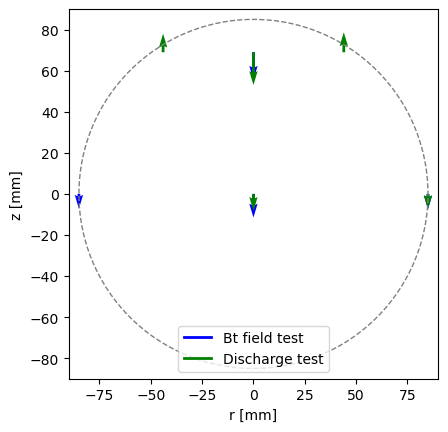

In [43]:
fig, ax = plt.subplots()
df_to_plot = df[(df.type == 'Bt test') | (df.type == 'Discharge test')]
grouped = df_to_plot.groupby(['r', 'z', 'type'])['x_v_y'].agg('mean').reset_index()
r = grouped['r'].to_numpy()
z = grouped['z'].to_numpy()
test_type = grouped['type'].to_list()
map_to_color = {"Bt test" : "blue", "Discharge test" : "green"}

test_colors = [map_to_color.get(n) for n in test_type]
mean = grouped['x_v_y'].to_numpy()

ax.quiver(r, z, np.zeros_like(mean), mean, color=test_colors,angles='xy')

# Add legend for arrows
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color='blue', lw=2, label='Bt field test'),
    Line2D([0], [0], color='green', lw=2, label='Discharge test')
]

# Add a circle with radius 85
circle = plt.Circle((0, 0), 85, color='gray', fill=False, linestyle='--', label='r=85')
ax.add_patch(circle)

ax.legend(handles=legend_elements, loc = 'lower center')


ax.set_xlabel('r [mm]')
ax.set_ylabel('z [mm]')
ax.set_xlim(-90, 90)
ax.set_ylim(-90, 90)
ax.set_aspect(1)
plt.show()

Text(0, 0.5, 'B_vertical / B_toroidal [-]')

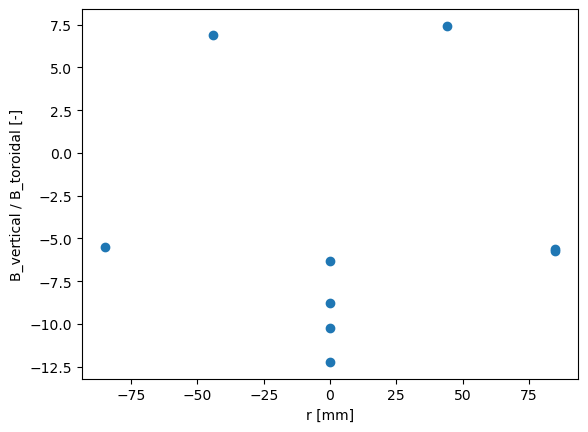

In [44]:
plt.scatter(r, mean*100)
plt.xlabel('r [mm]')
plt.ylabel('B_vertical / B_toroidal [-]')

In [45]:
df['x_y_angle'] = np.rad2deg(np.arcsin(df.x_v_y))

In [46]:
df[(df.type == 'Bt test') | (df.type == 'Discharge test')]

,type,U_cd,U_bt,t_cd,t_bt,O_cd,O_bt,r,z,comment,x_v_y,x_max,x_y_angle
shot_no,,,,,,,,,,,,,
44658,Bt test,0.0,100.0,0.0,0.0,CW,CW,0,69,"3D hall probe calibration - Bt test, r=0,z=69 m\n",-0.100602,-0.537284,-5.773833
44659,Bt test,0.0,500.0,0.0,0.0,CW,CW,0,69,"3D hall probe calibration - Bt test 2, r=0,z=6...",-0.103442,-3.493764,-5.937429
44660,Bt test,0.0,1200.0,0.0,0.0,CW,CW,0,69,"3D hall probe calibration - Bt test 3, r=0,z=6...",-0.103326,-8.182848,-5.930713
44673,Discharge test,200.0,200.0,1000.0,0.0,CW,CW,0,69,3D hall probe calibration - params for modest ...,-0.122250,-1.557620,-7.021954
44679,Discharge test,200.0,200.0,1000.0,0.0,CW,CW,-44,69,3D hall probe calibration - params for dischar...,0.069073,13.674220,3.960752
44684,Discharge test,200.0,200.0,1000.0,0.0,CW,CW,44,69,3D hall probe calibration - params for dischar...,0.074282,11.513312,4.259980
46271,Bt test,0.0,200.0,NaN,NaN,CW,CW,-85,0,"3D hall probe calibration - r=-0.85,z=0, Bt sc...",-0.055389,-1.899000,-3.175185
46272,Bt test,0.0,400.0,NaN,NaN,CW,CW,-85,0,"3D hall probe calibration - r=-0.85,z=0, Bt sc...",-0.053204,-4.820000,-3.049832
46273,Bt test,0.0,600.0,NaN,NaN,CW,CW,-85,0,"3D hall probe calibration - r=-0.85,z=0, Bt sc...",-0.052100,-5.445000,-2.986483


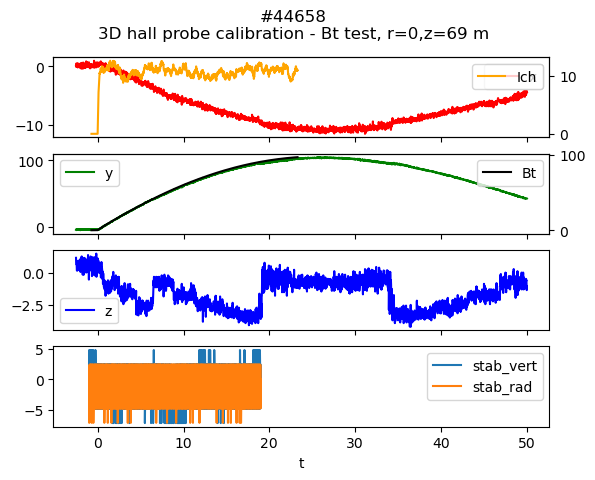

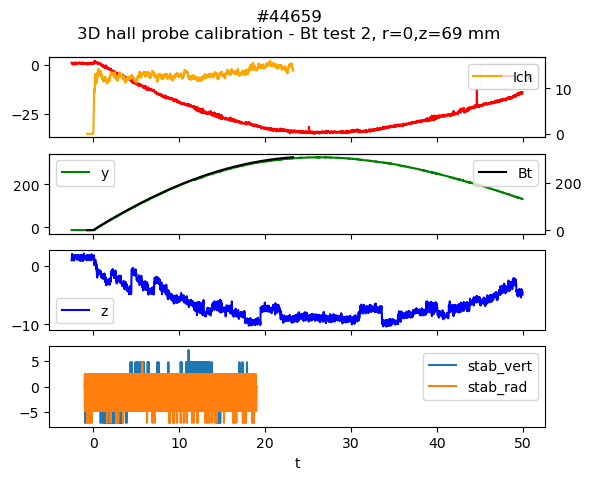

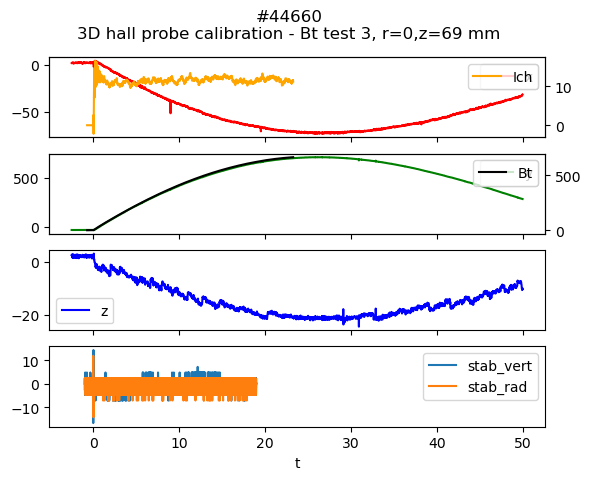

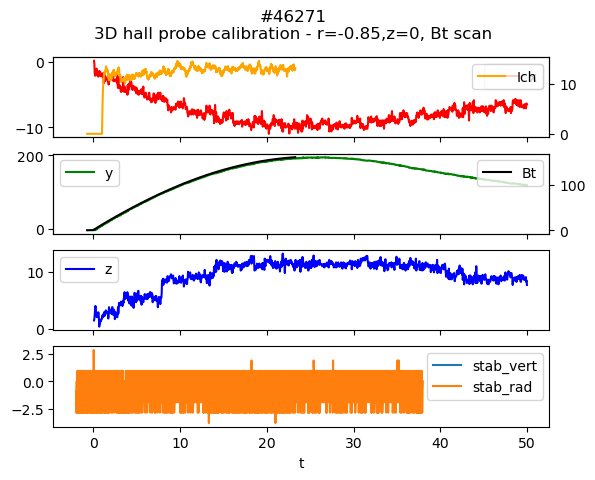

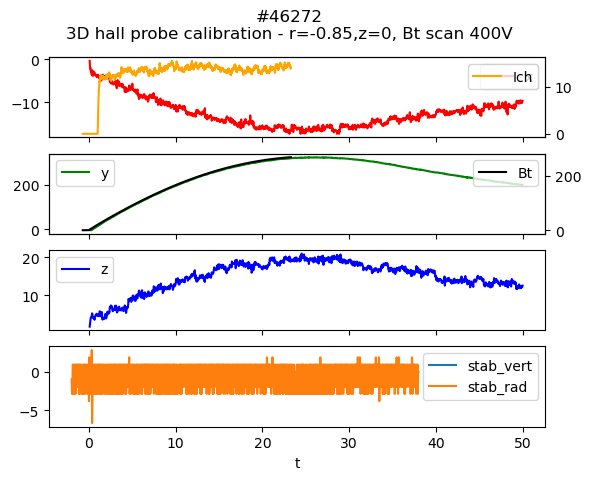

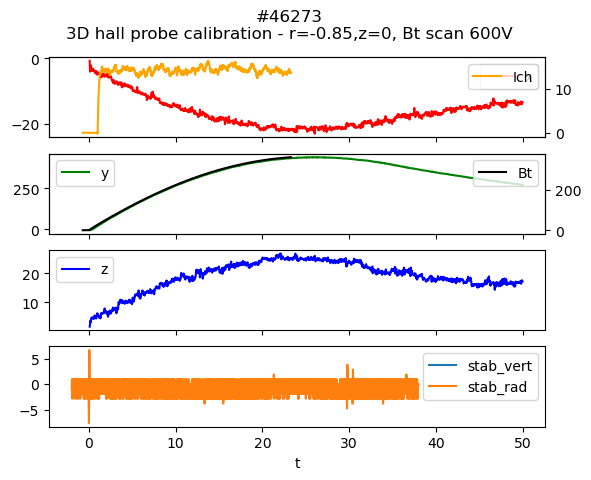

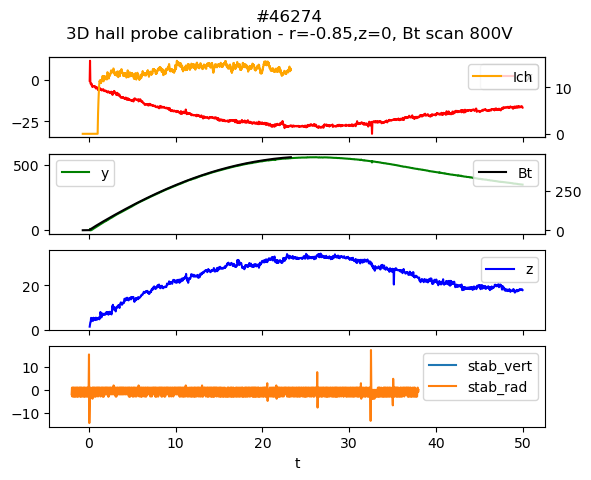

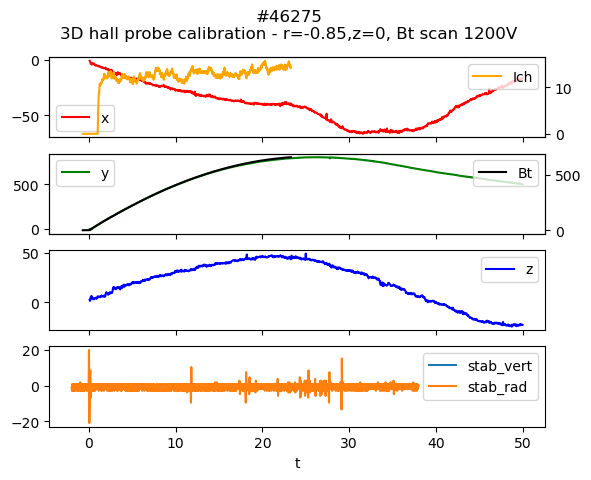

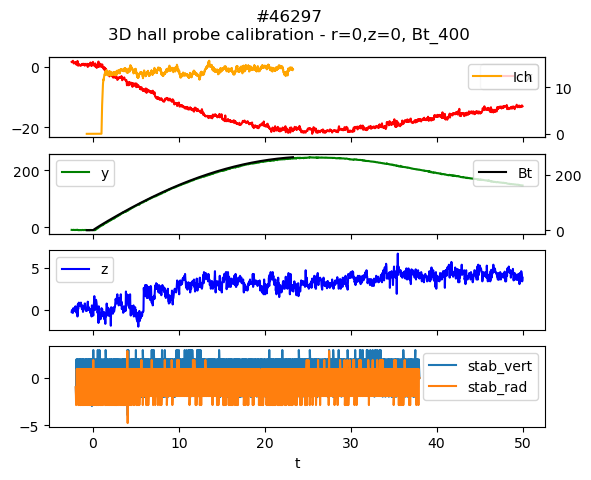

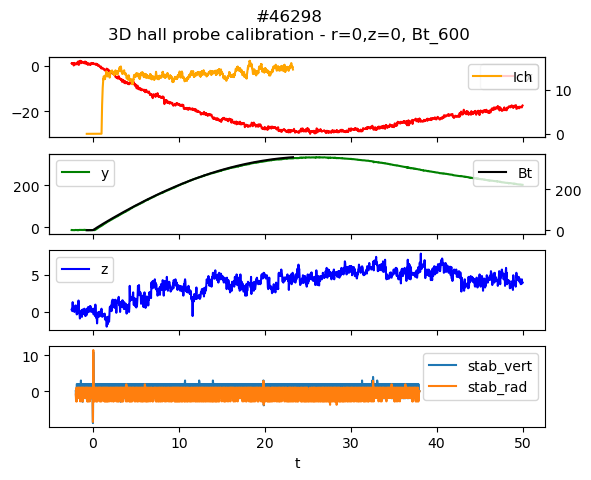

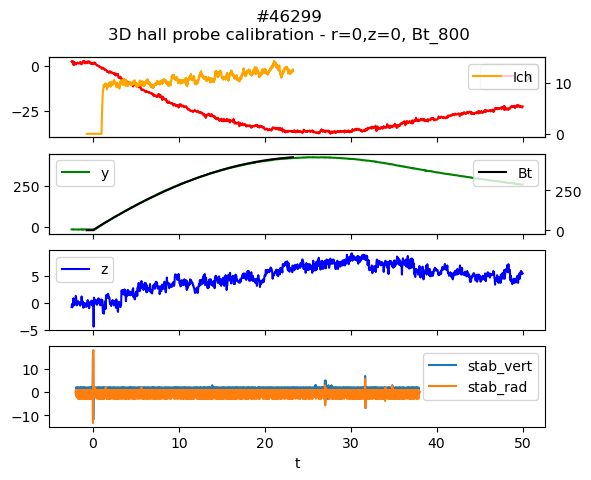

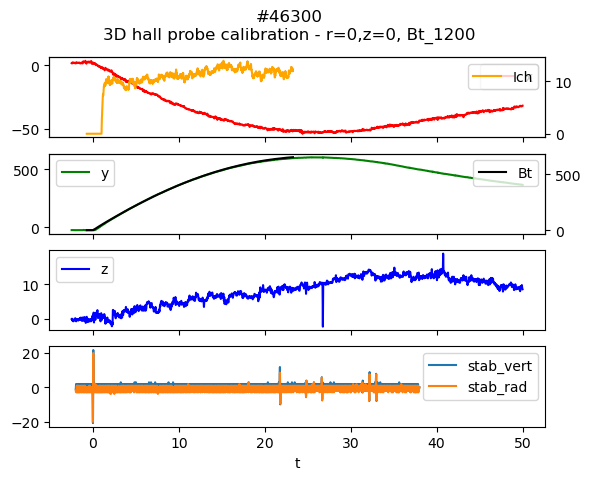

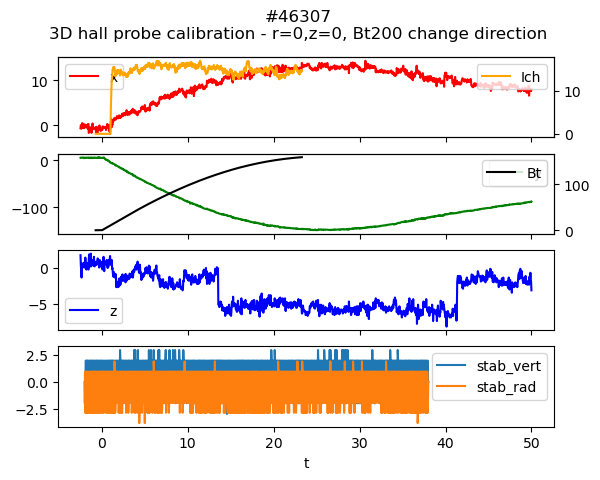

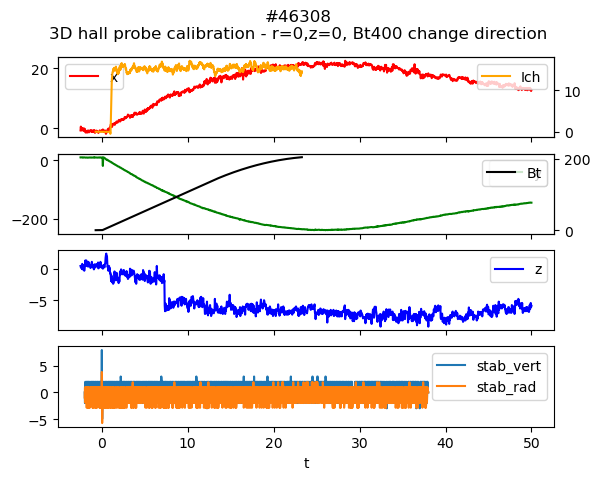

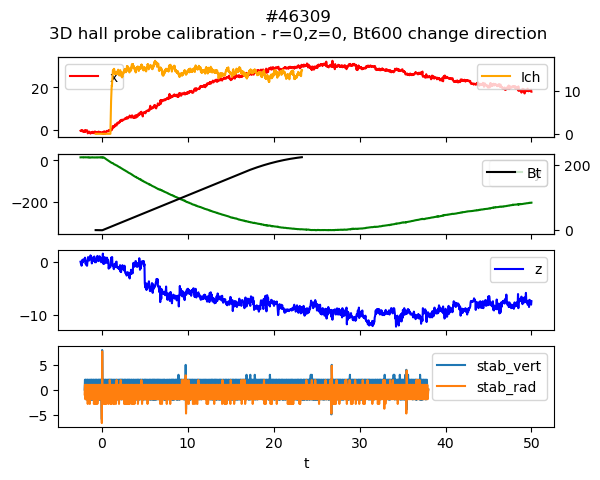

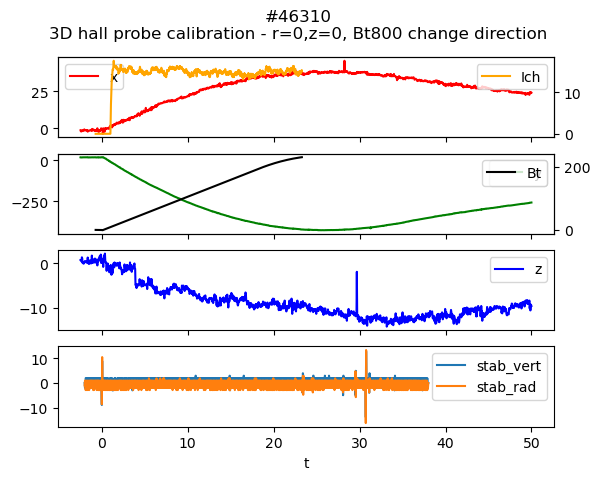

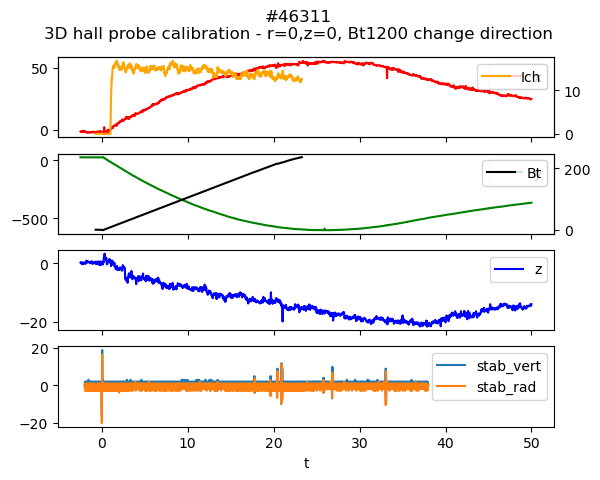

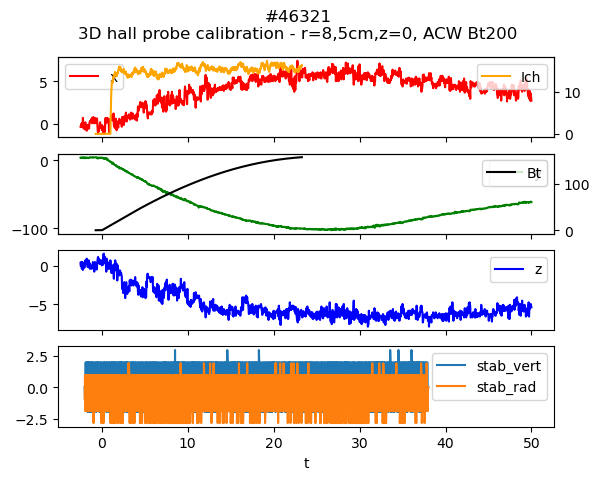

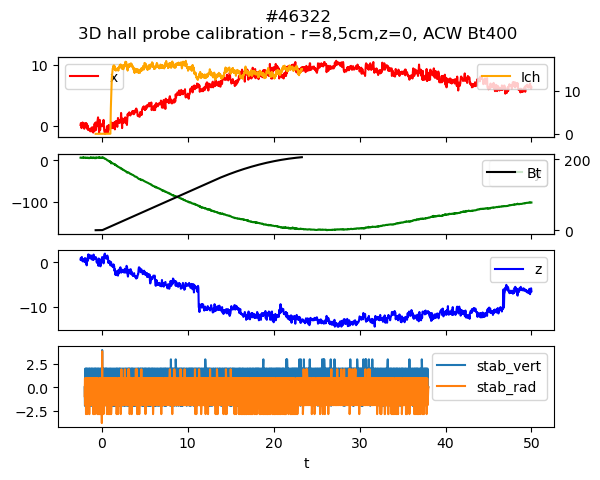

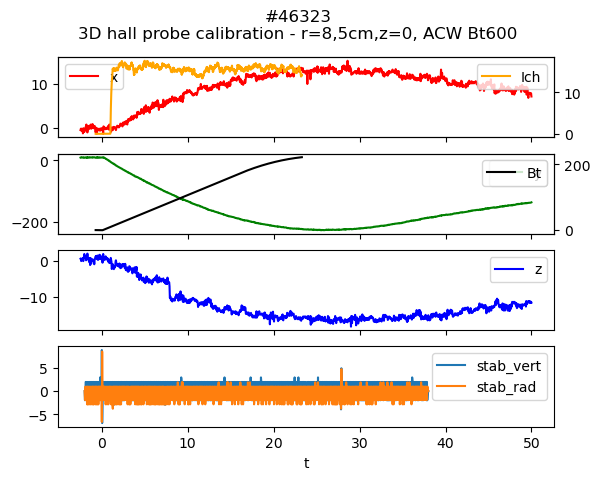

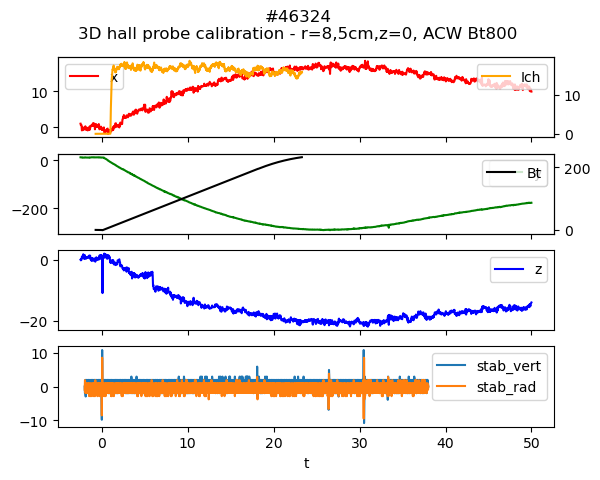

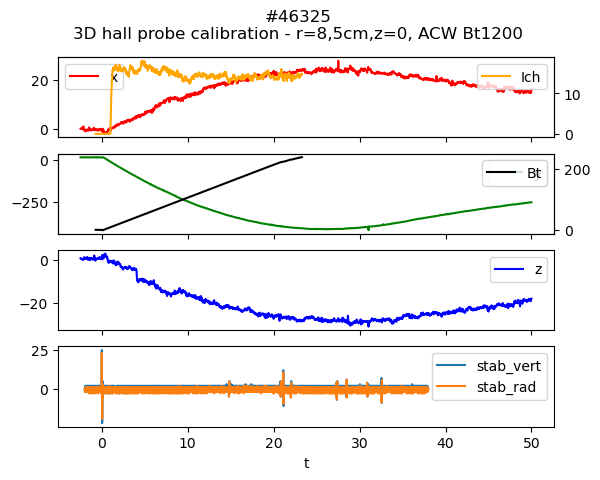

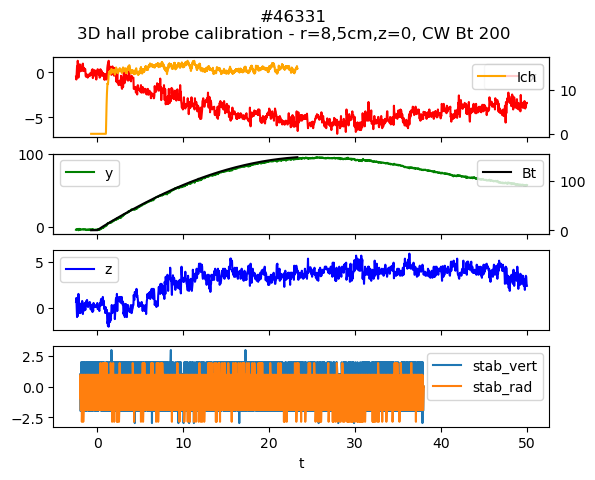

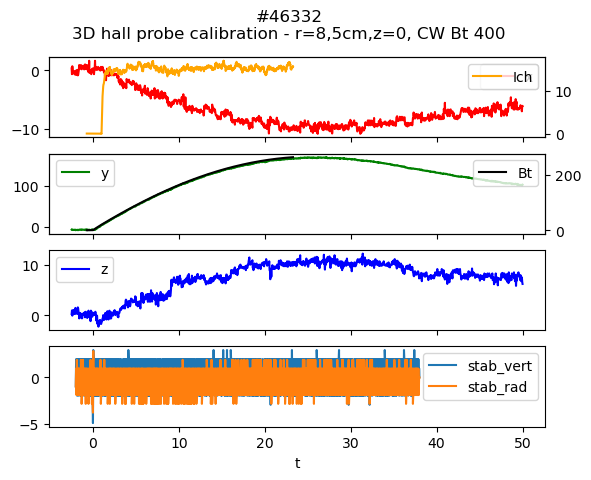

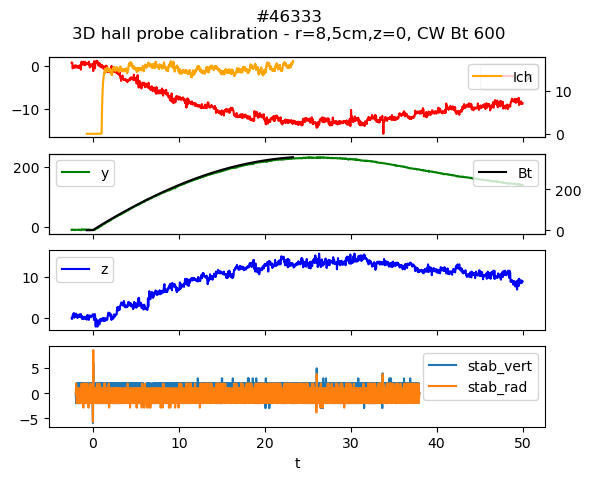

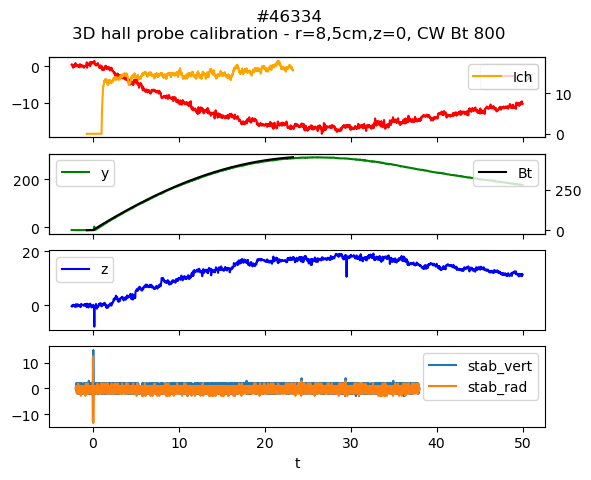

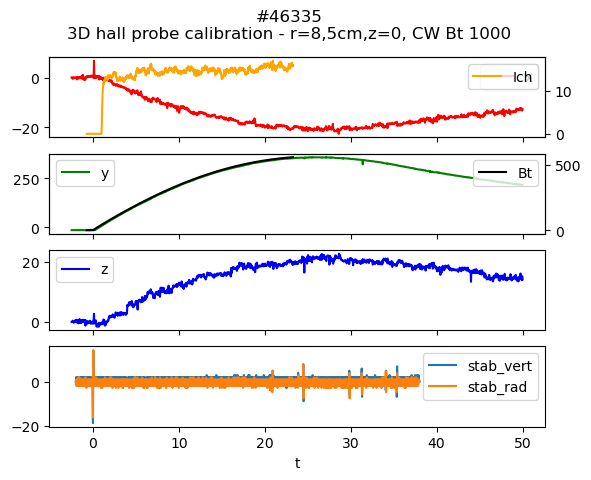

In [47]:
for shot_no,_ in df[df.type == 'Bt test'].iterrows():
    plot(shot_no, window=0)

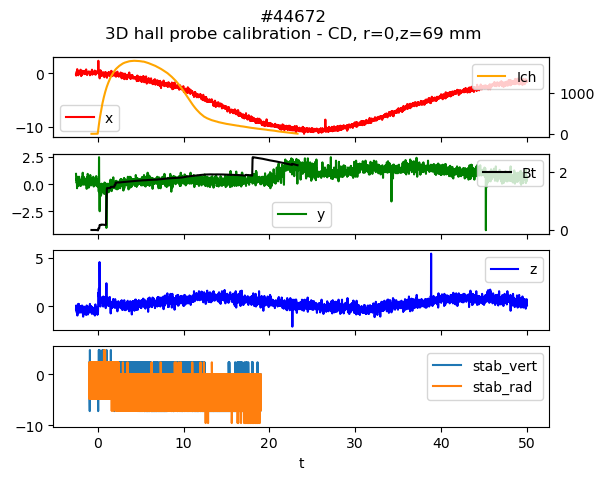

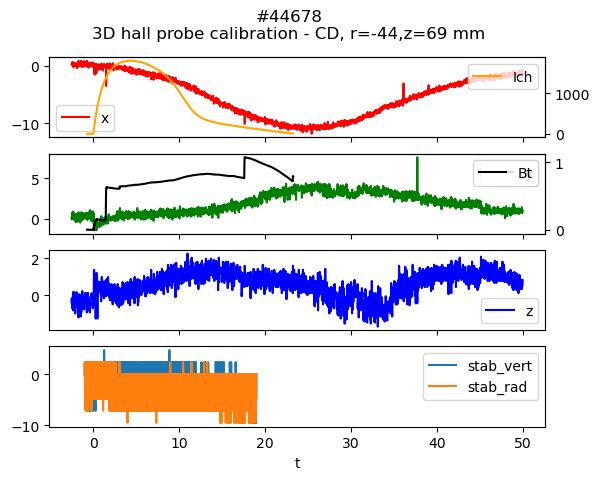

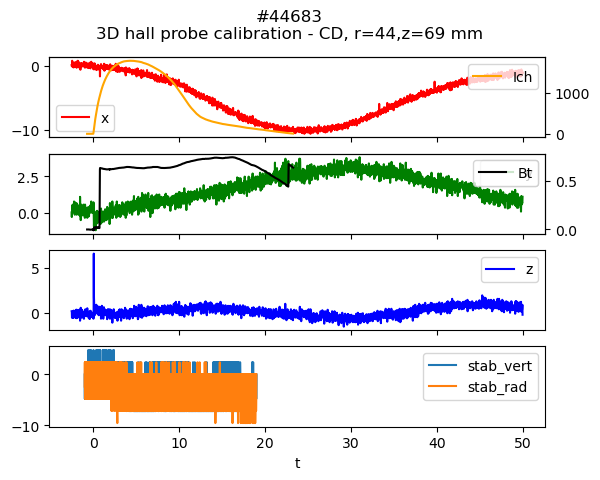

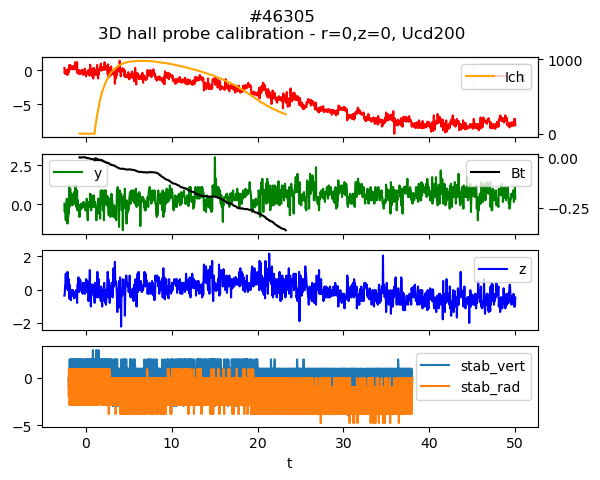

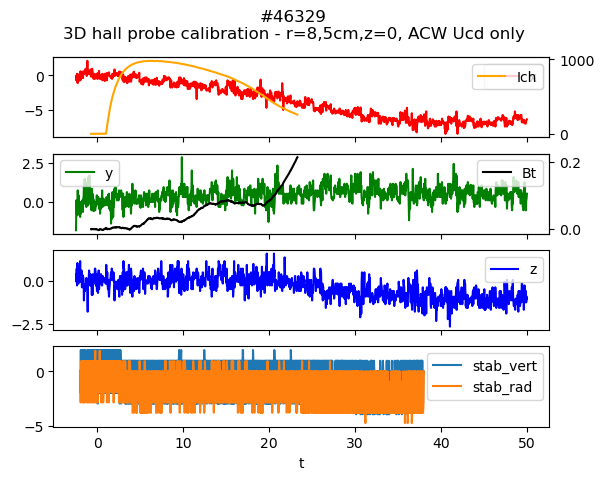

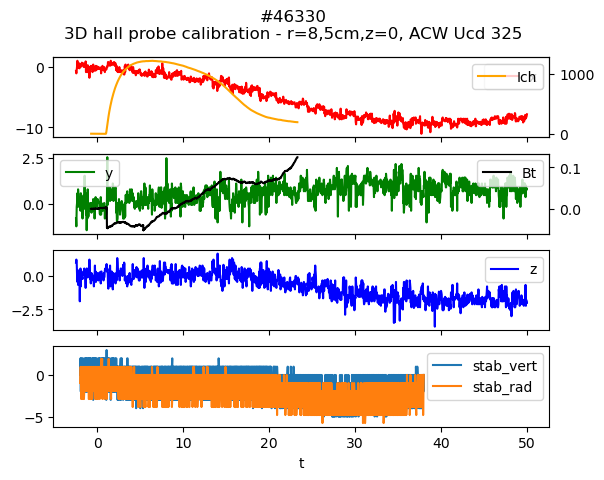

In [48]:
for shot_no,_ in df[df.type == 'CD test'].iterrows():
    plot(shot_no, window=0)

## All data plotted

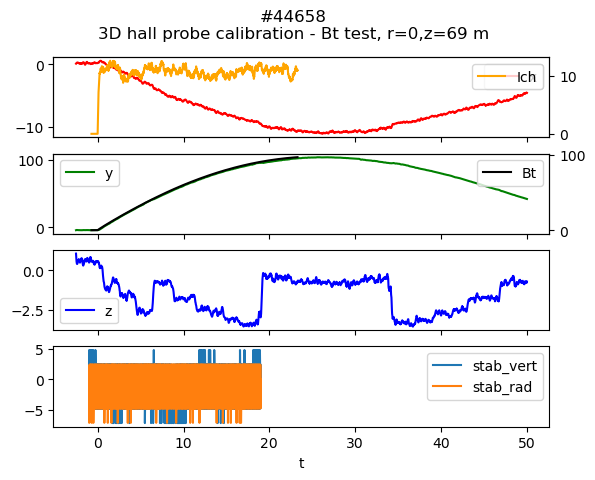

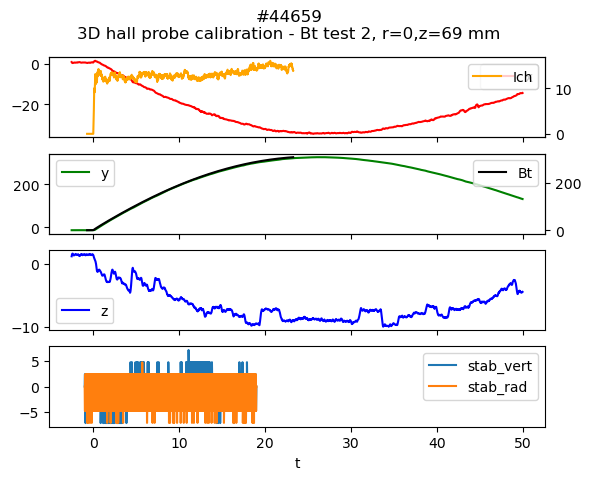

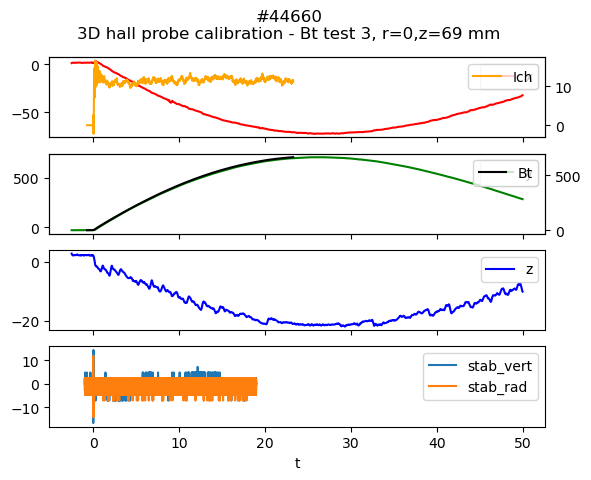

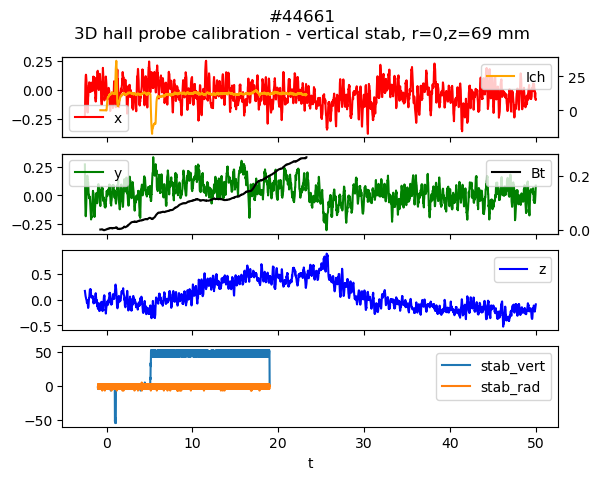

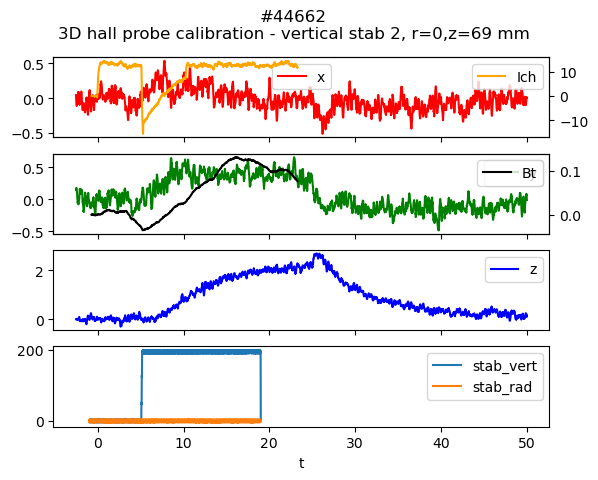

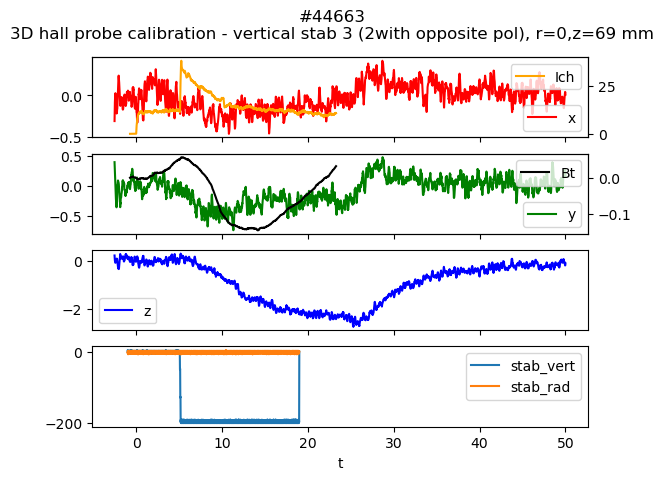

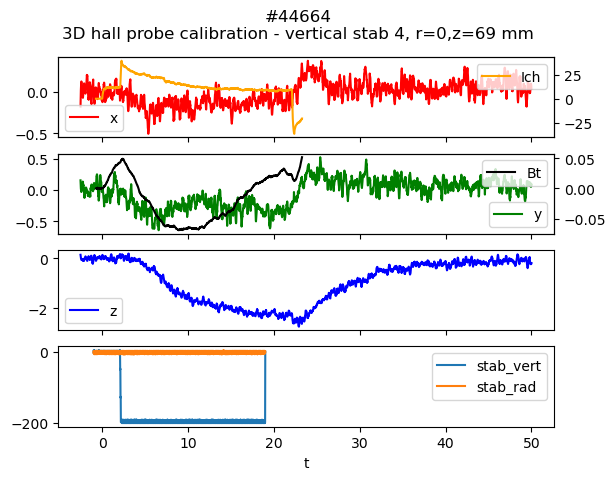

44665  MSL file not found
44666  MSL file not found
44667  MSL file not found
44668  MSL file not found
44669  MSL file not found
44670  MSL file not found


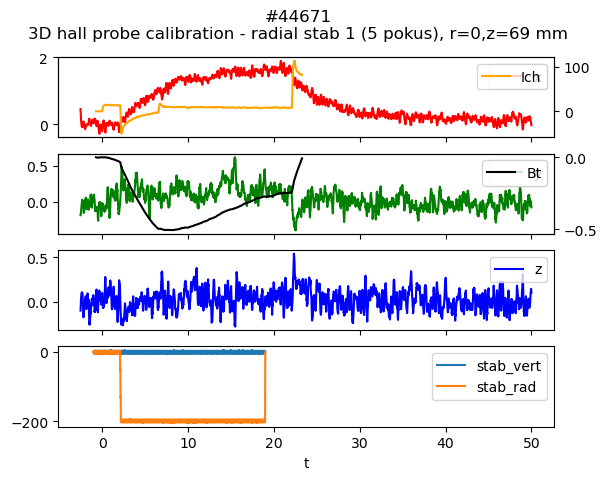

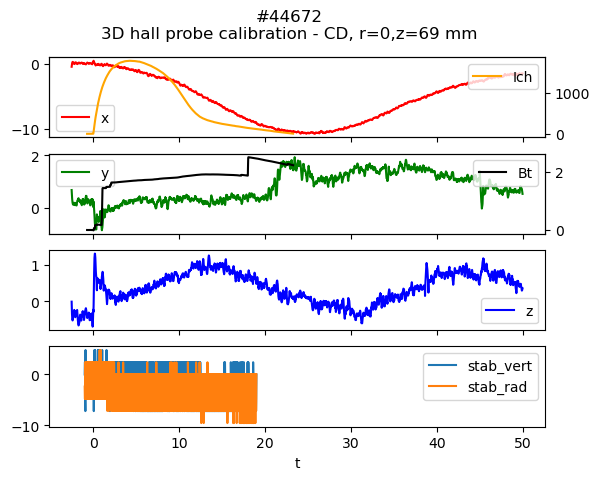

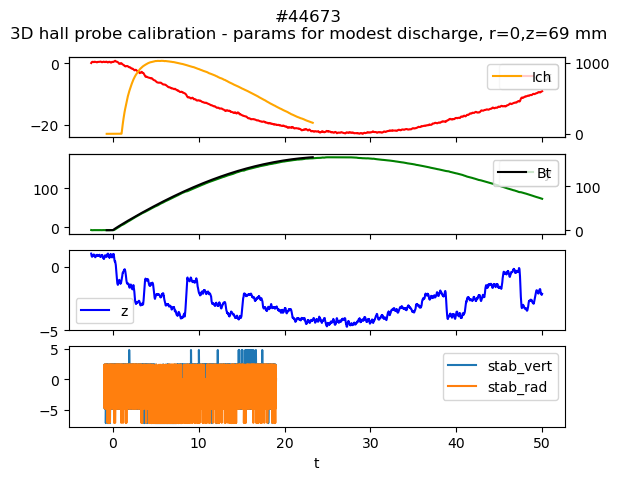

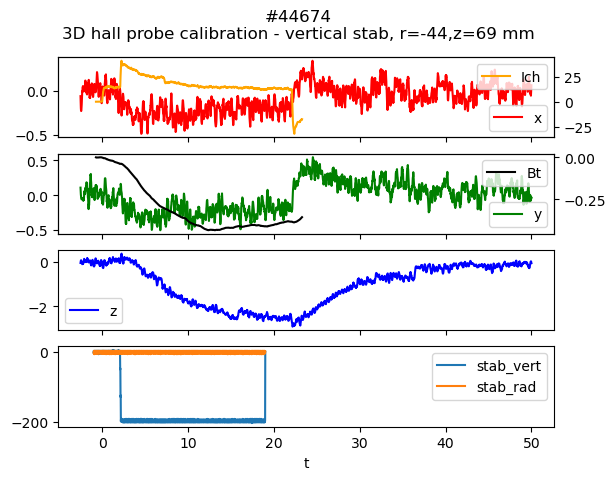

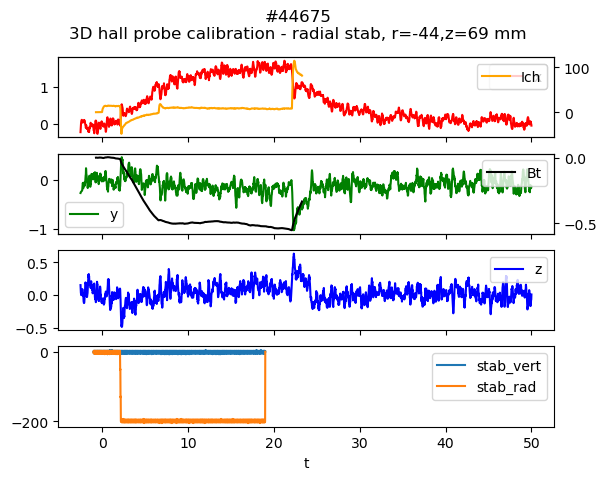

44676  MSL file not found


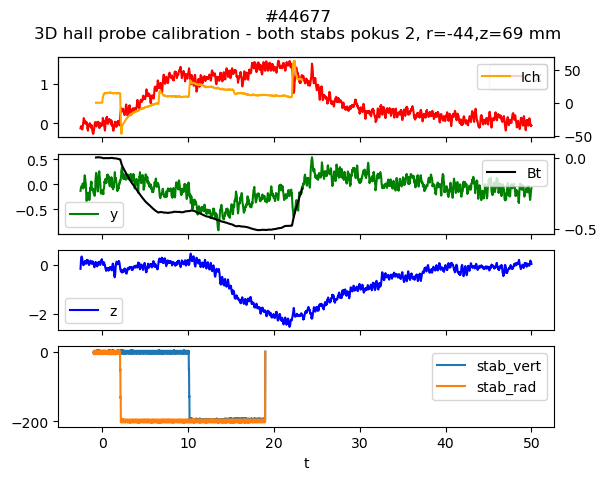

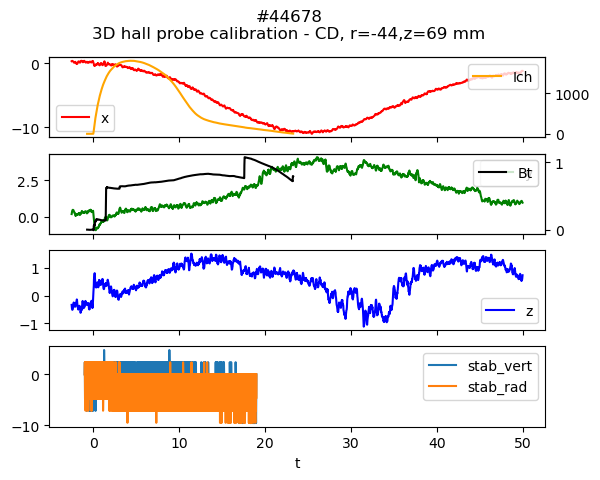

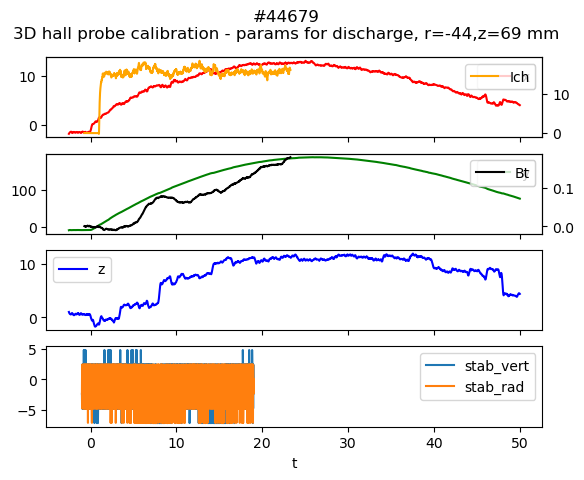

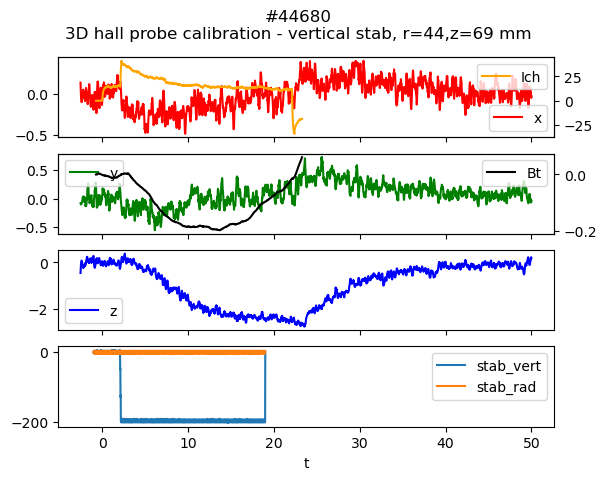

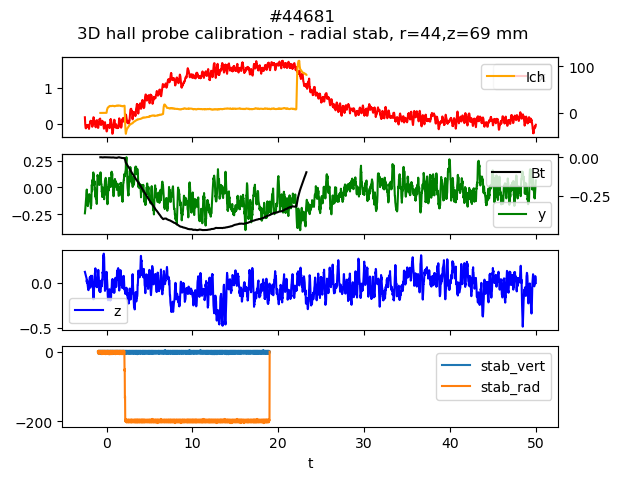

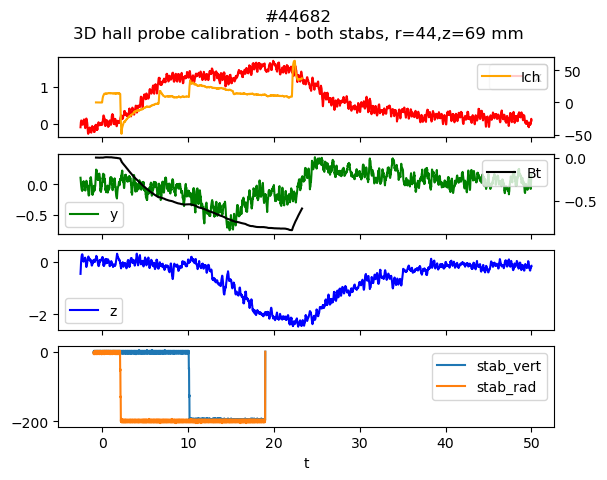

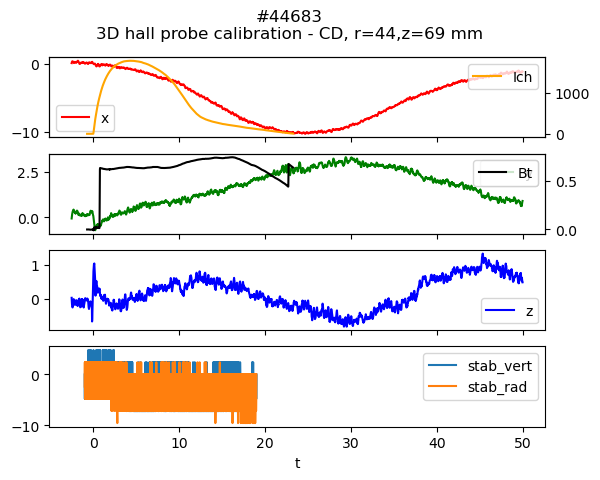

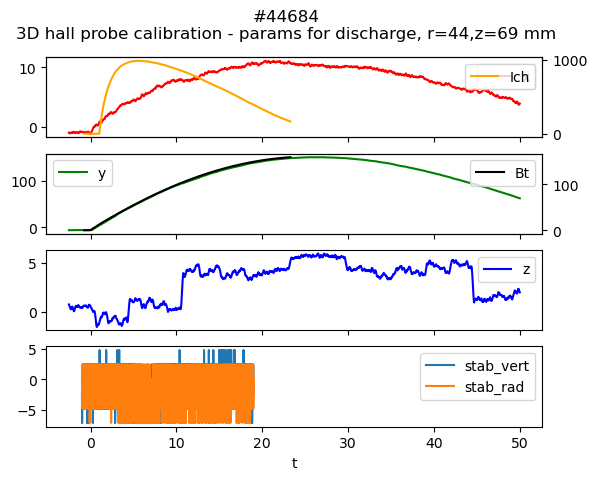

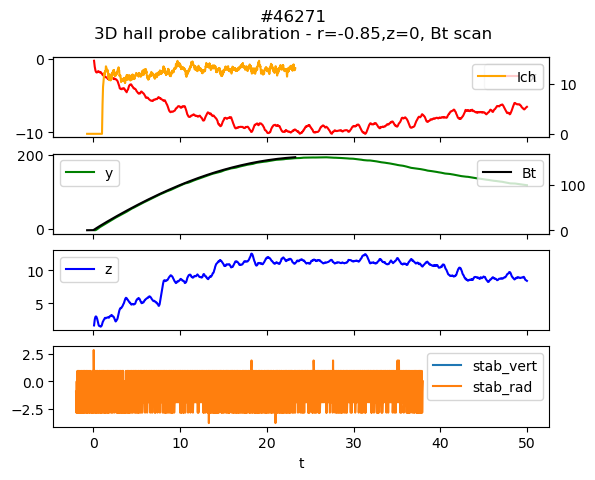

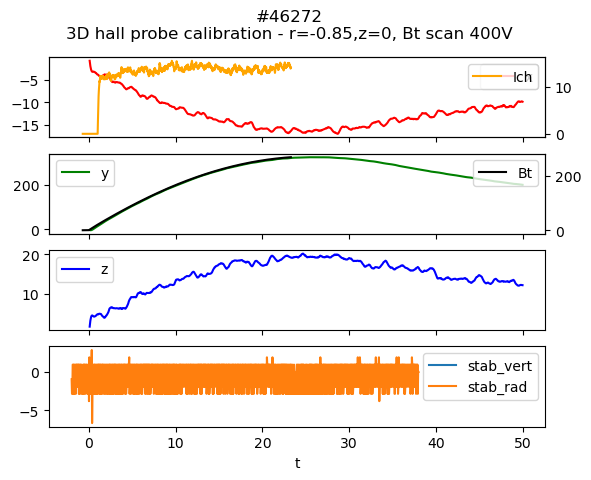

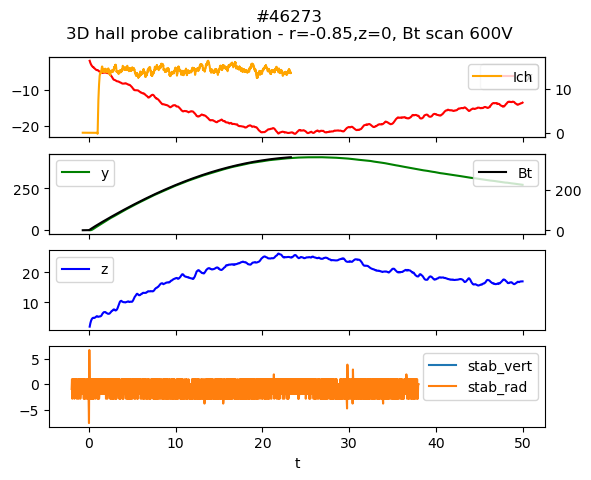

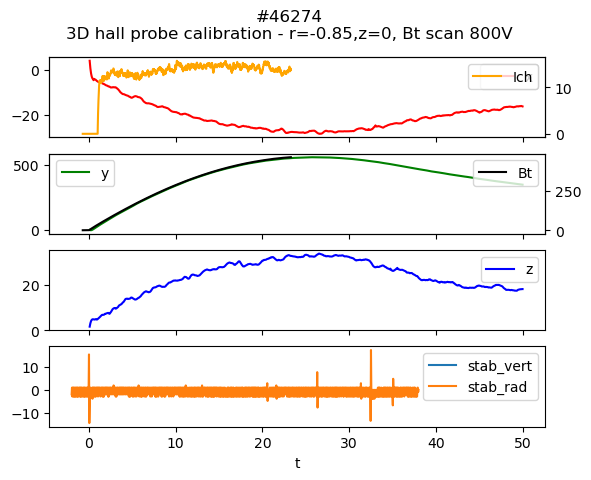

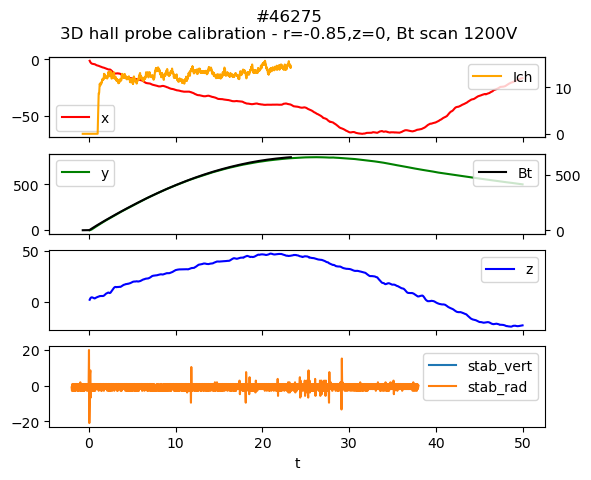

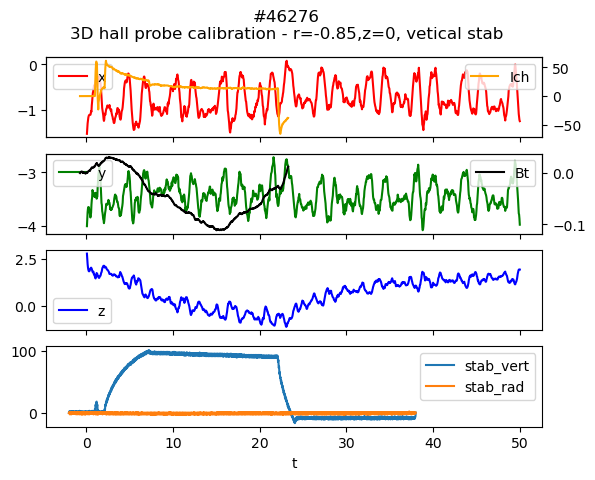

46277  MSL file not found


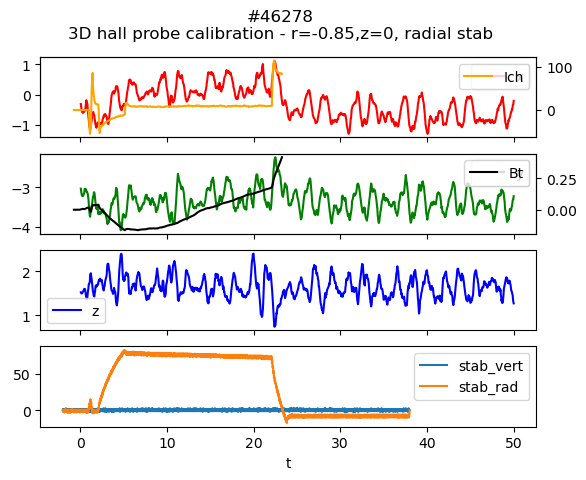

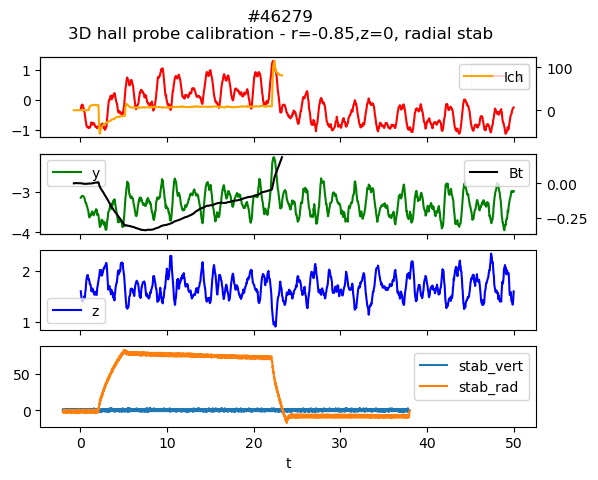

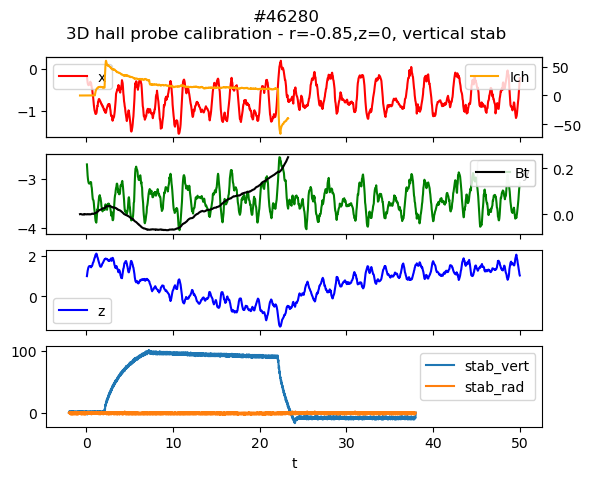

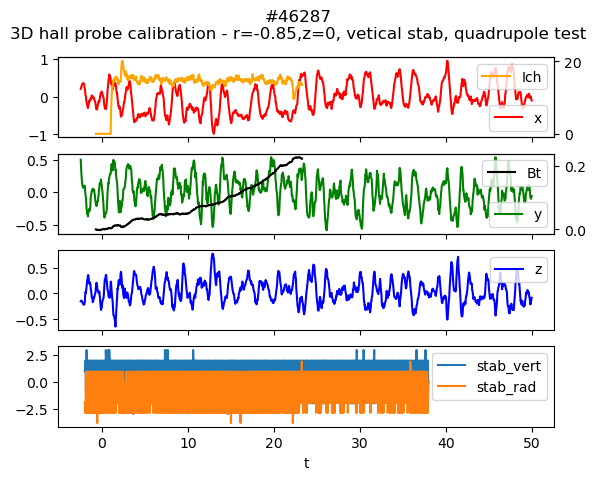

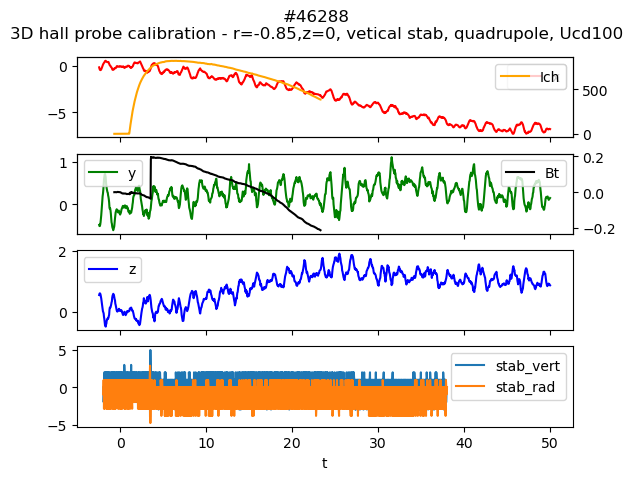

46289  MSL file not found


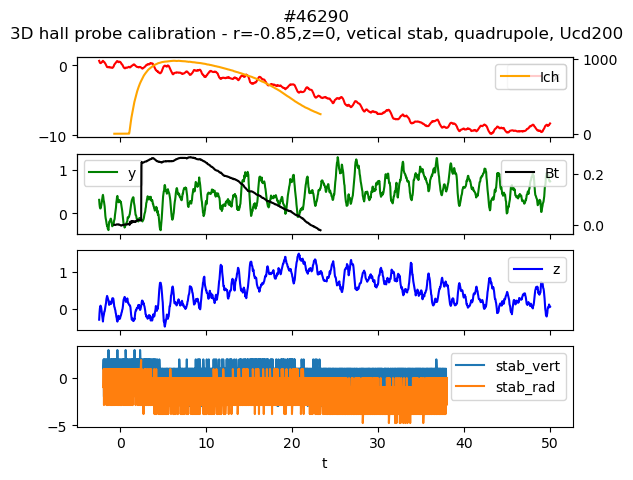

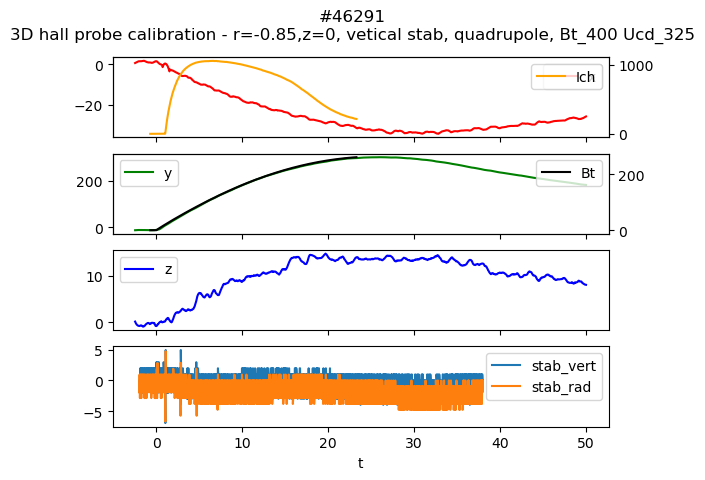

46292  MSL file not found


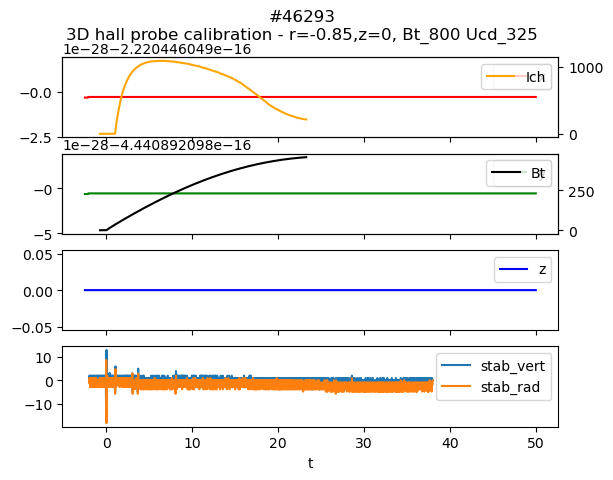

46294  MSL file not found


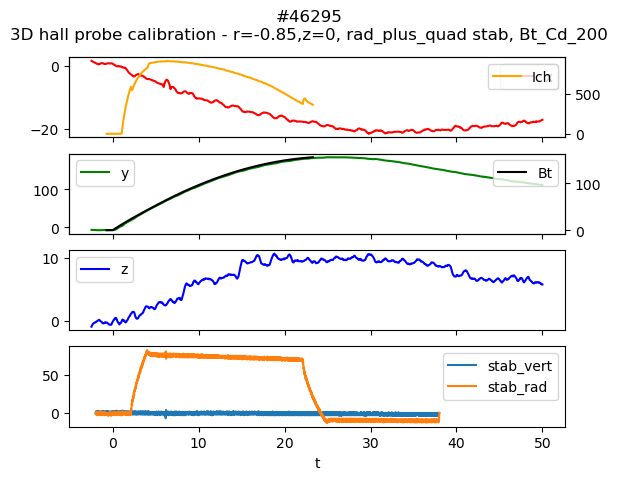

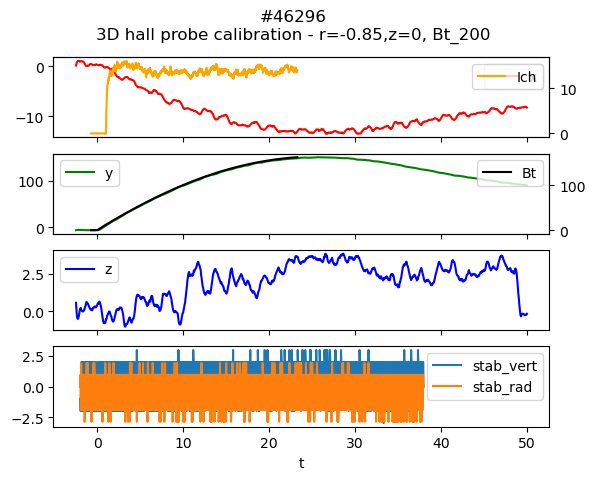

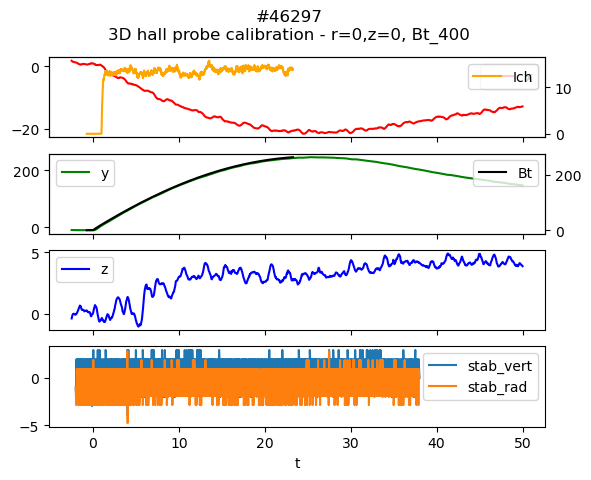

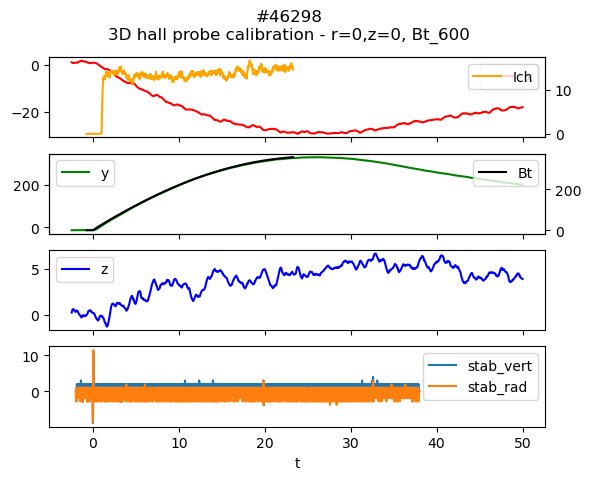

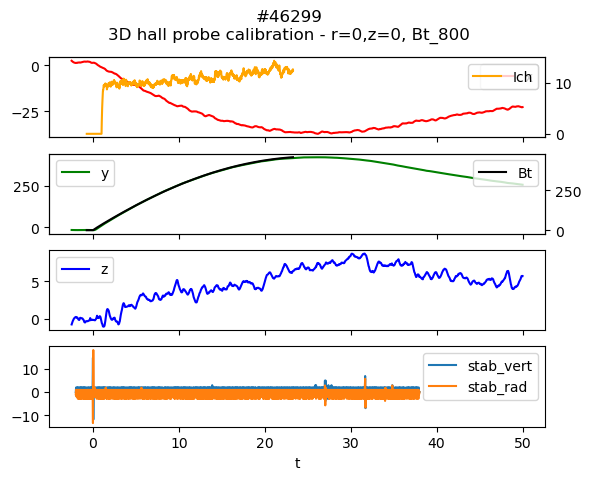

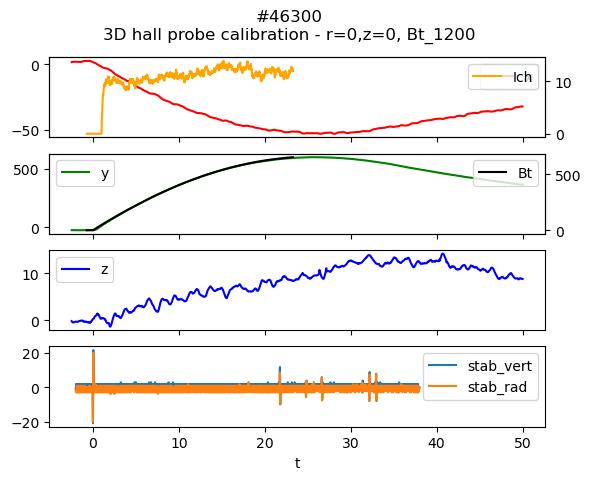

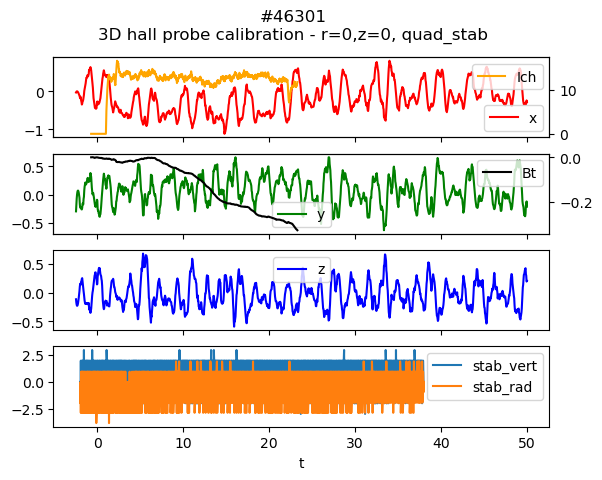

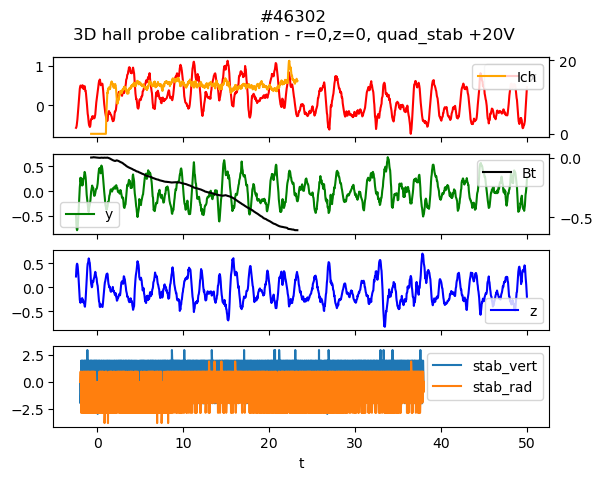

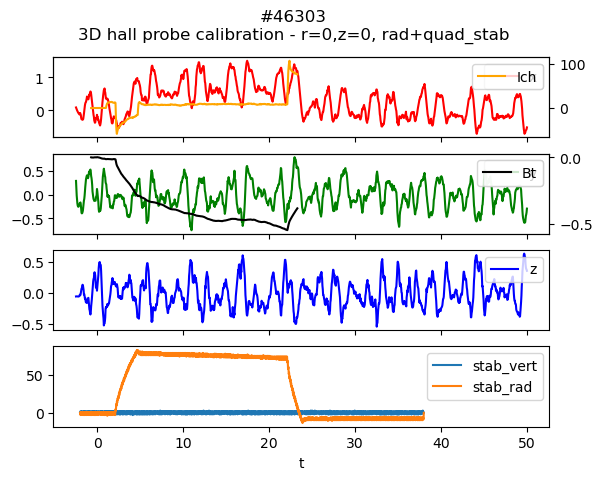

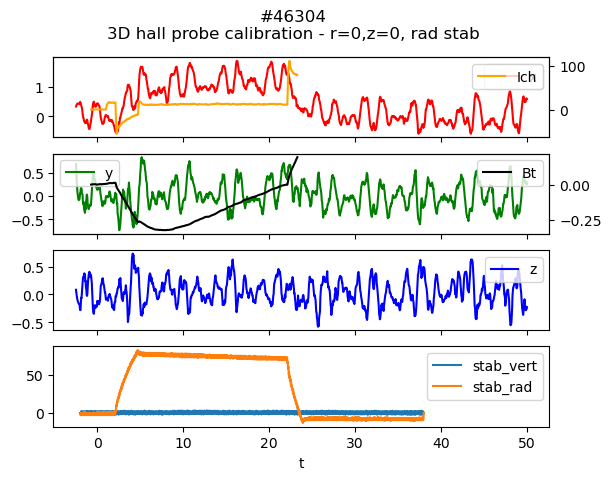

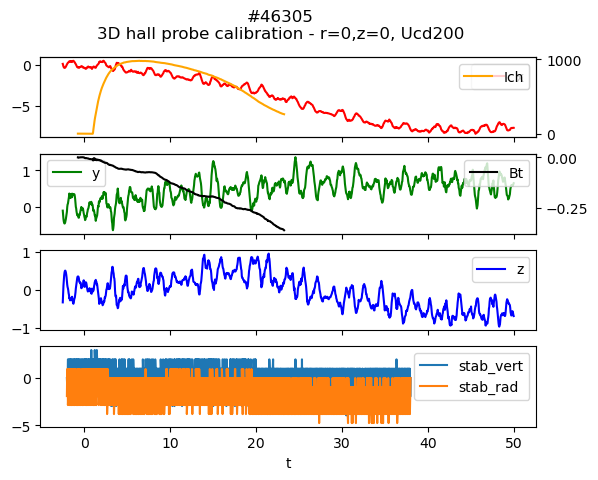

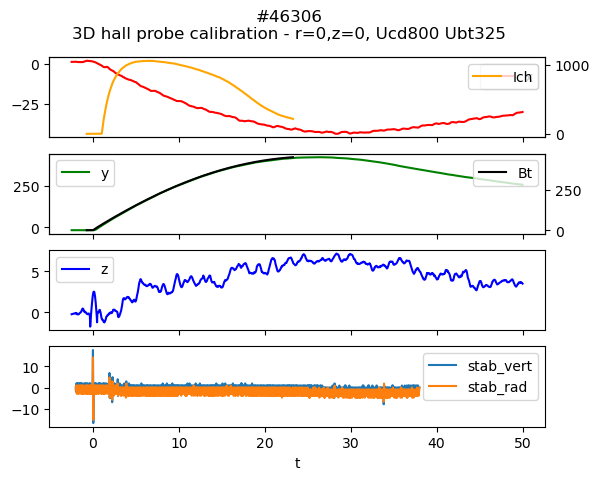

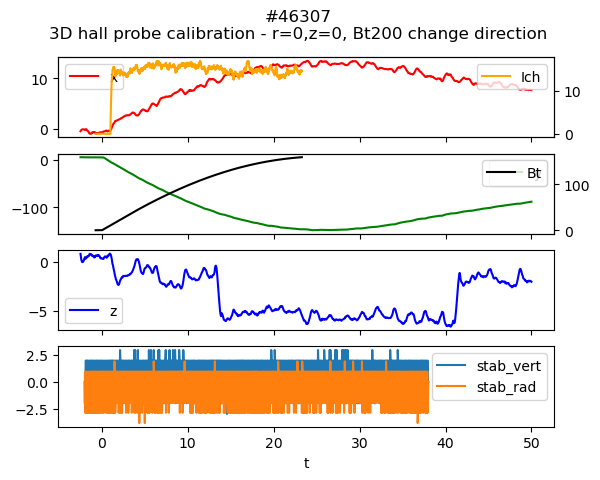

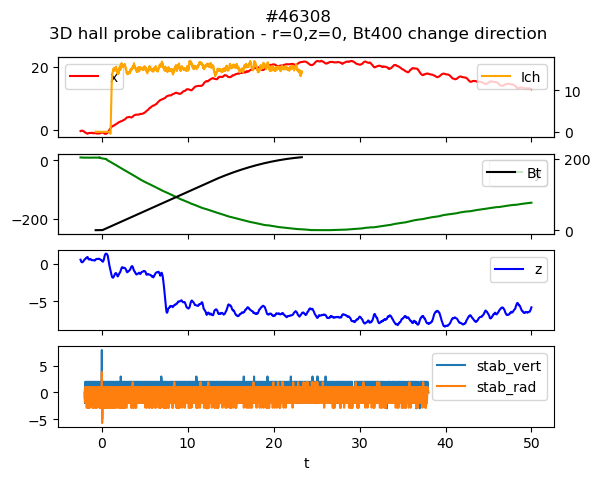

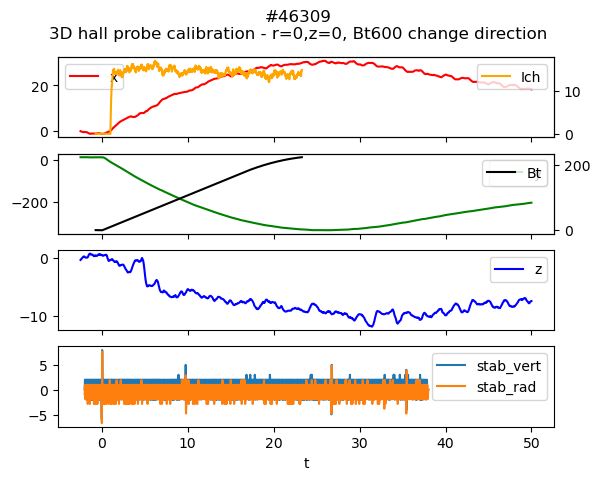

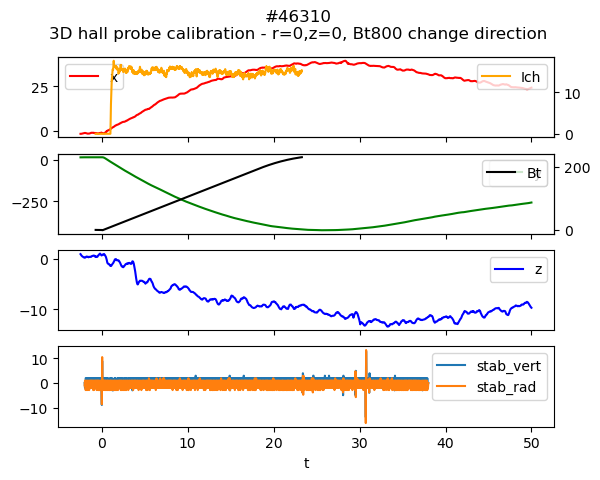

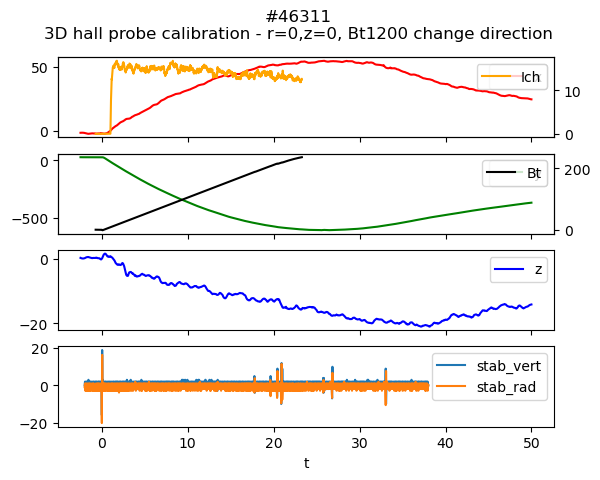

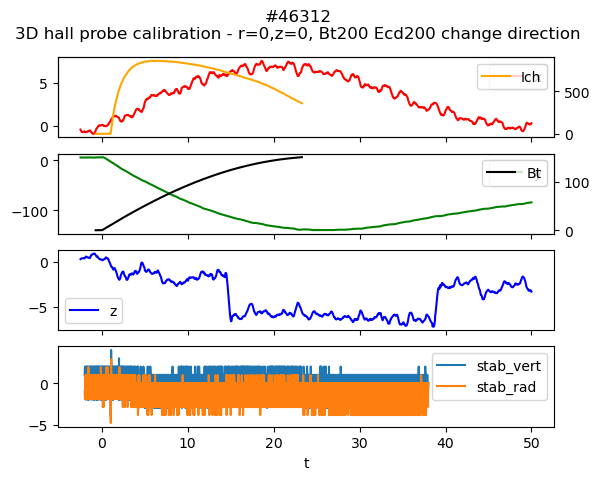

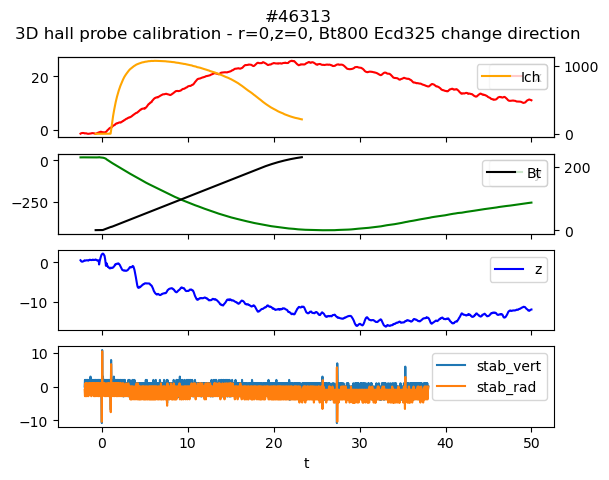

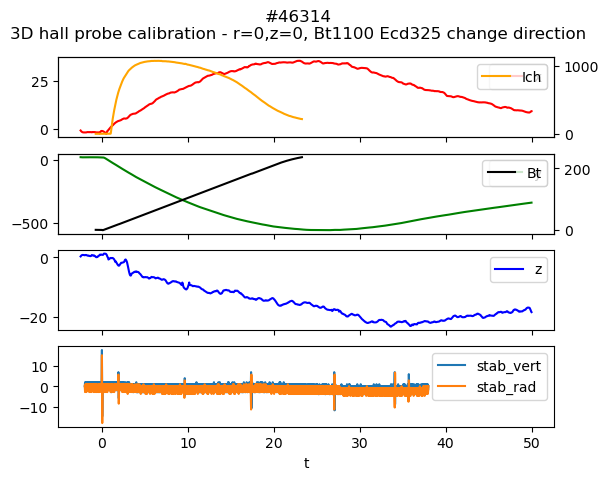

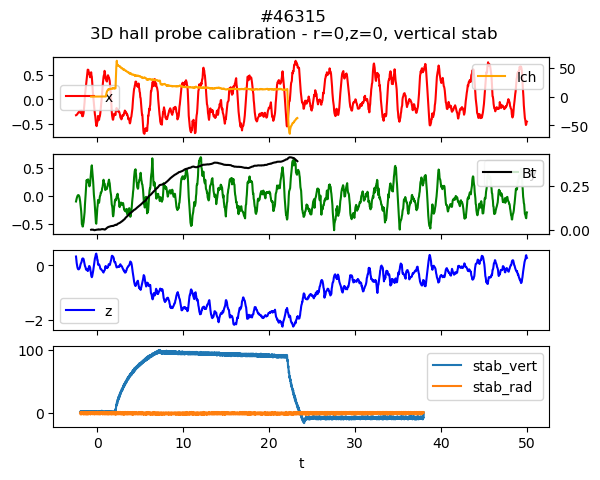

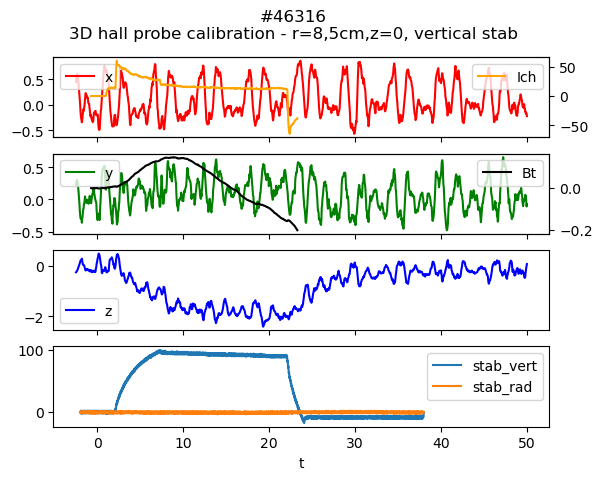

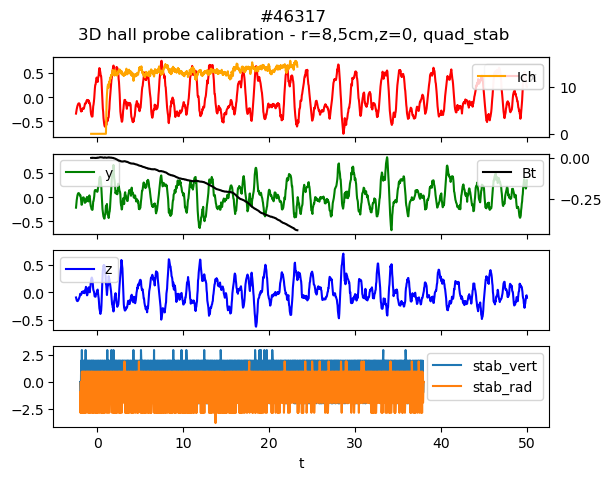

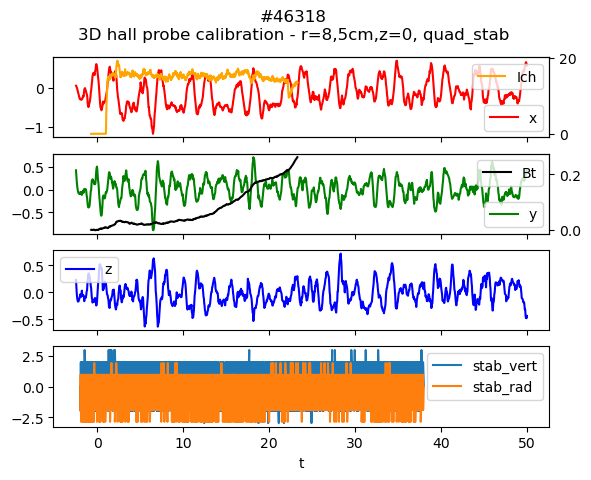

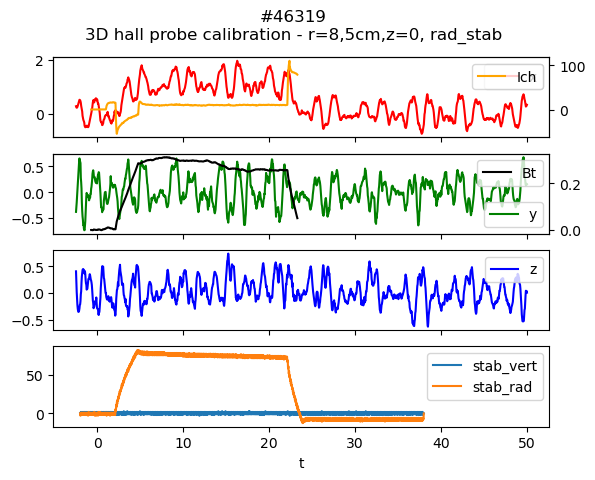

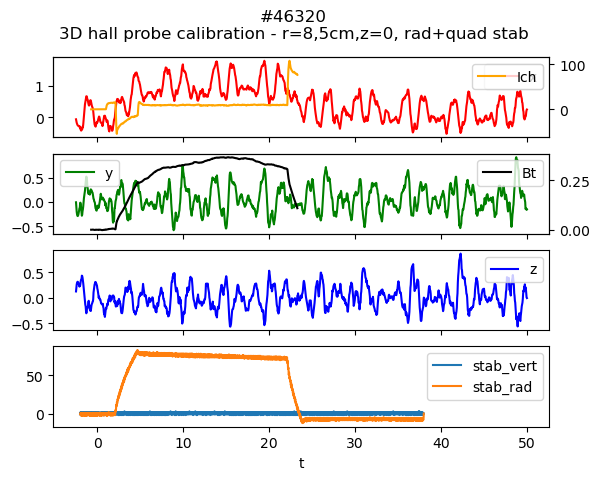

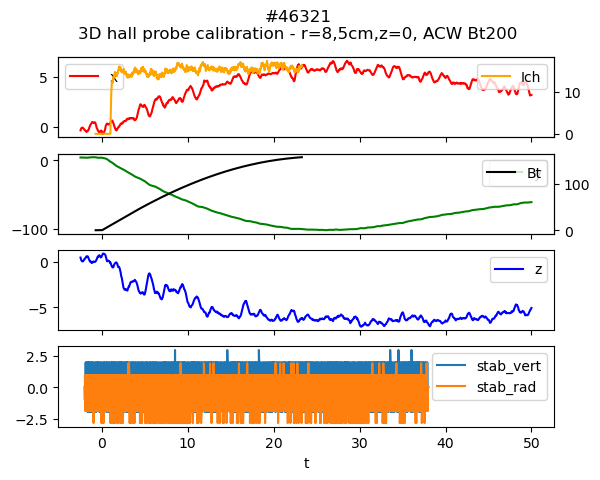

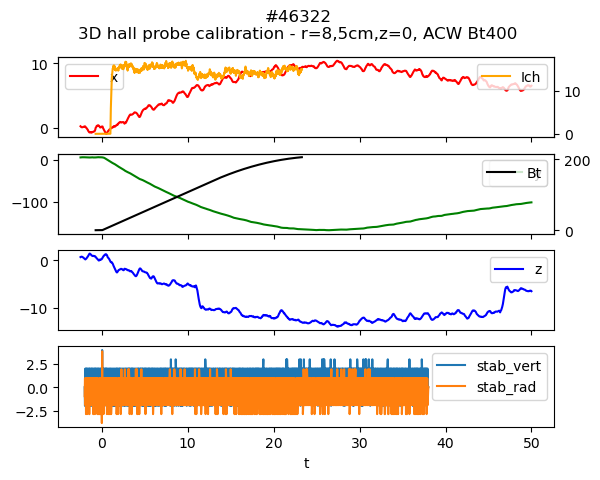

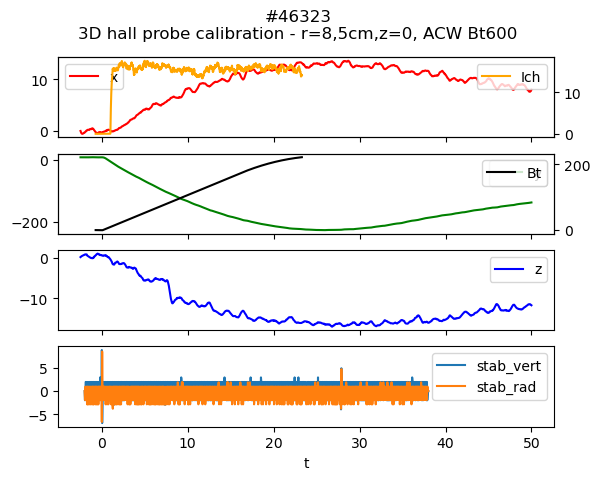

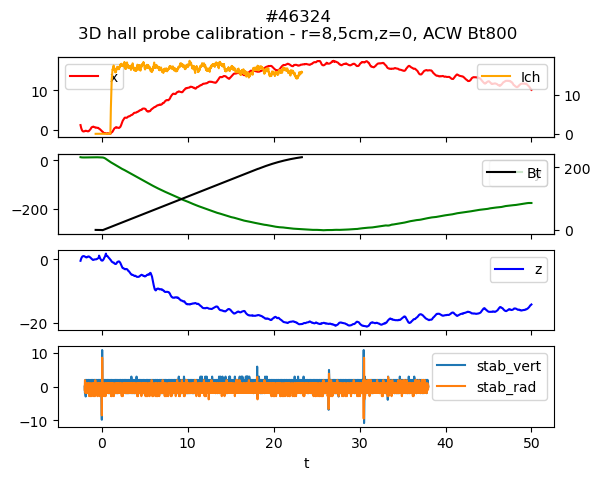

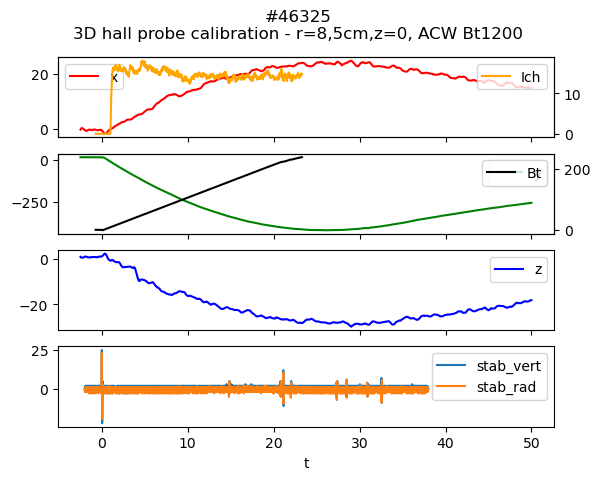

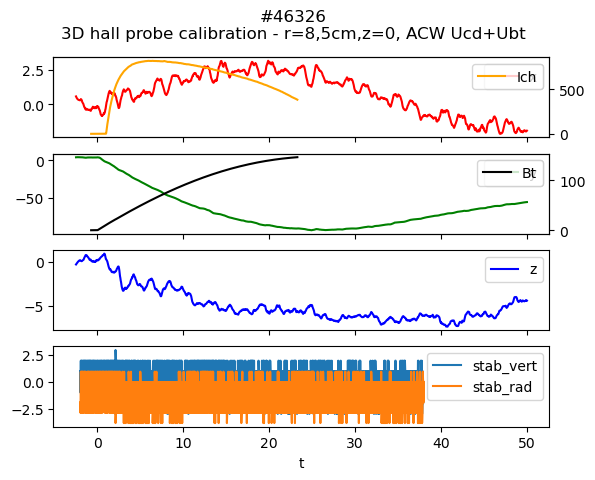

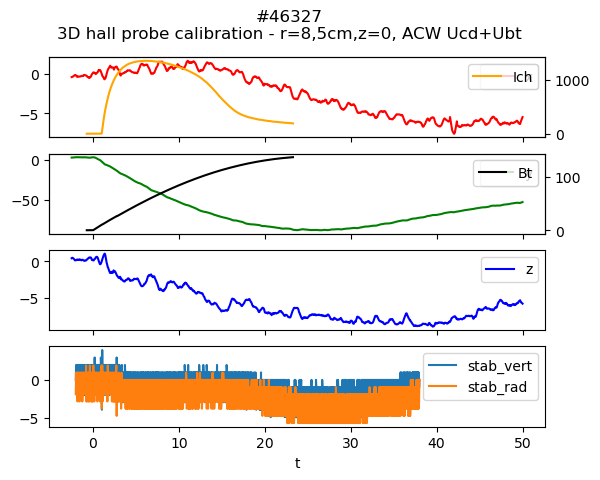

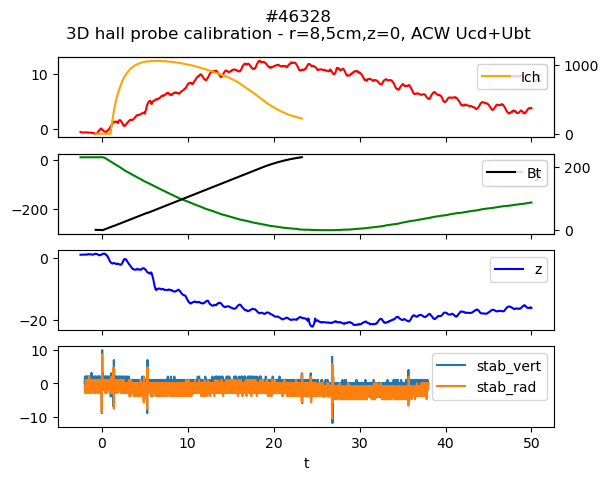

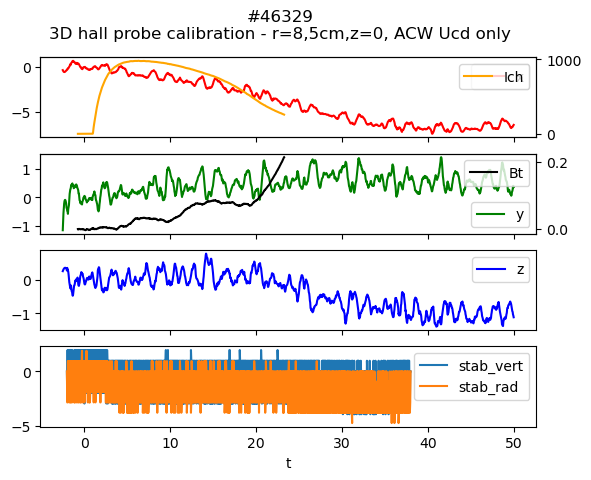

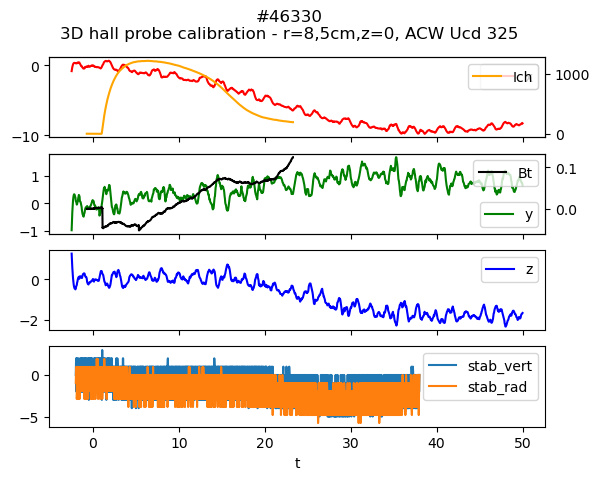

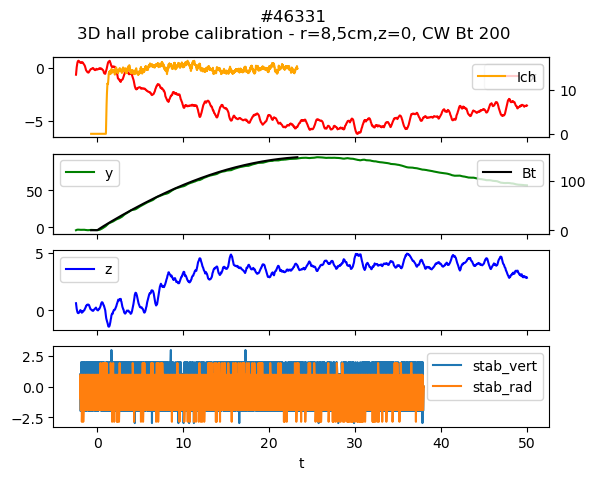

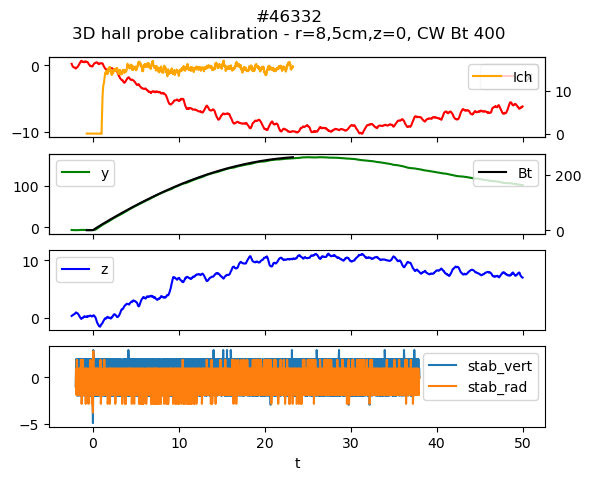

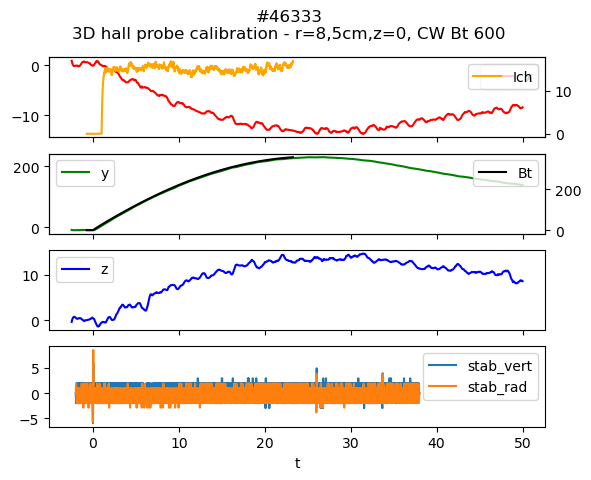

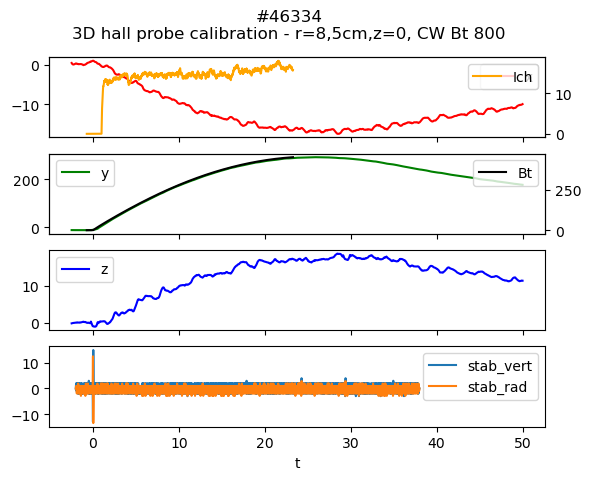

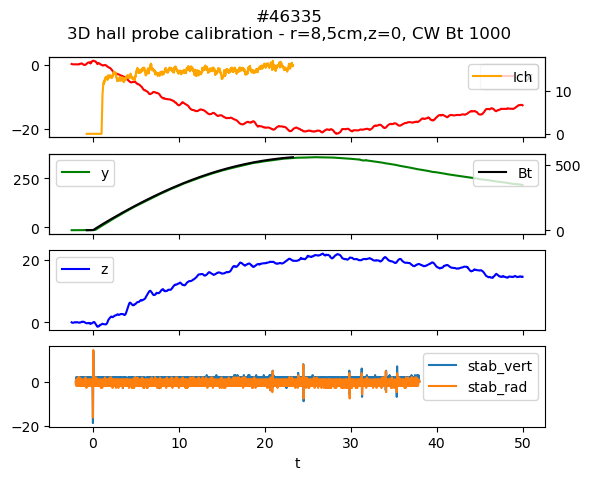

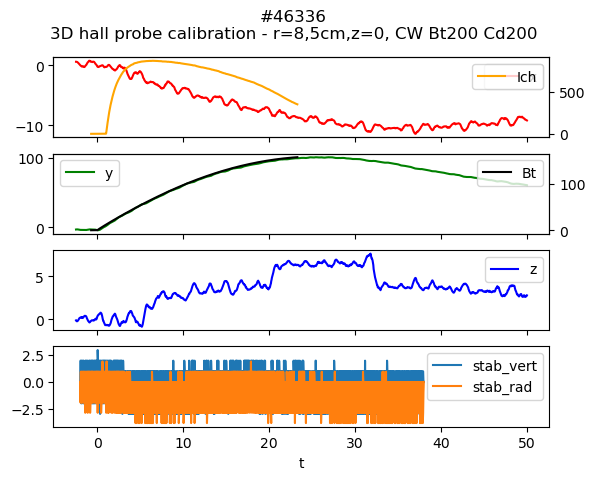

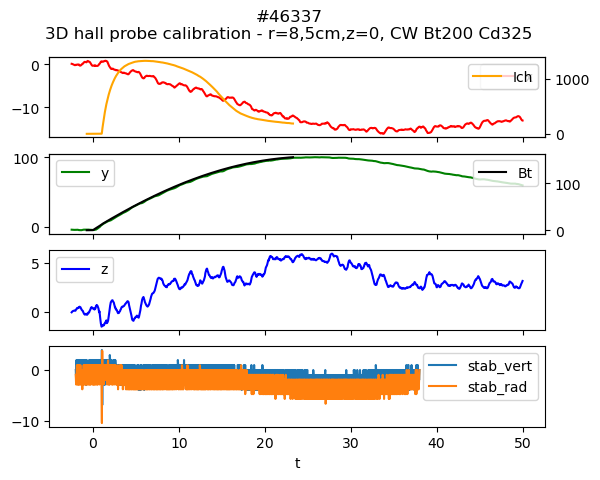

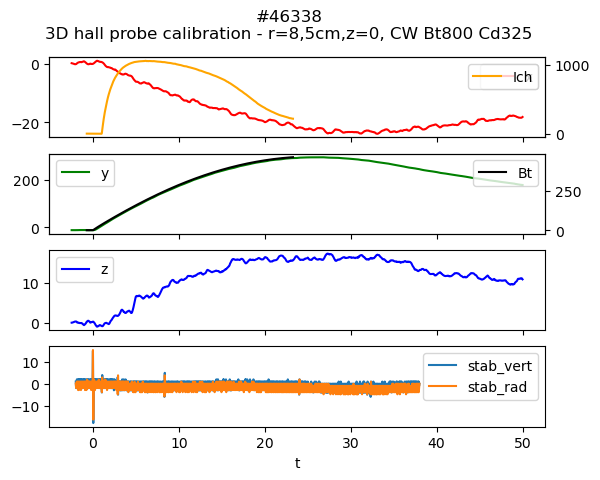

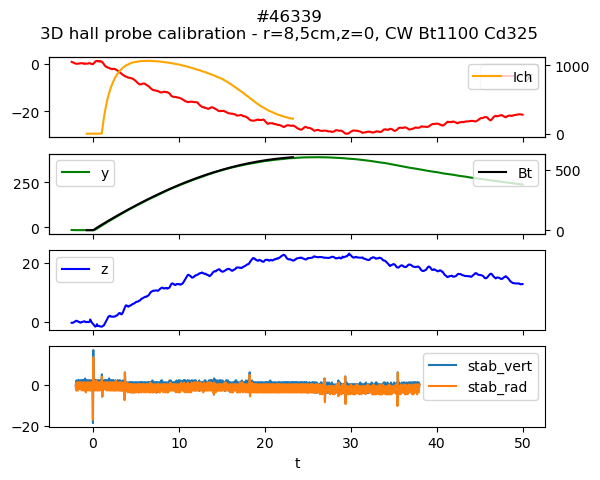

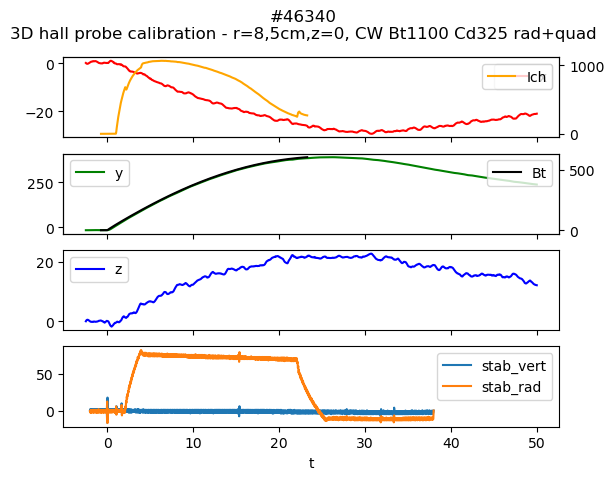

In [49]:
for s_n in list(range(44658,44685)) + list(range(46271,46281)) + list(range(46287,46341)):
    try:
        plot(s_n)
    except FileNotFoundError:
        print(s_n, ' MSL file not found')